🚀 INITIALISIERUNG: Architektur & Physik (Elastisches CM mit fairer Fatigue)...
🧠 Trainiere KI auf Leistung & elastische Gesundheit (mit Fatigue-Awareness)...


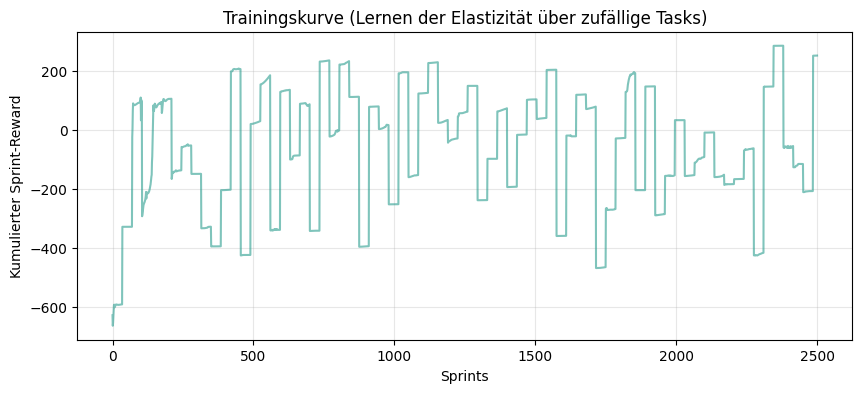

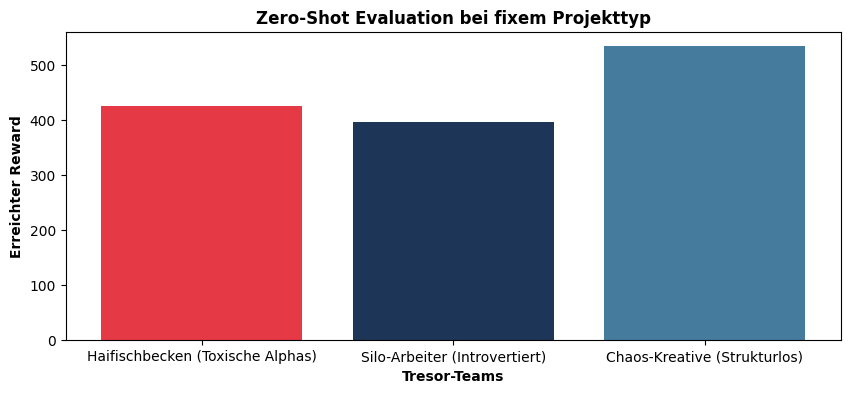

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random

# =====================================================================
# DIE MAGISCHE ZAHL FÜR REPRODUZIERBARKEIT (SEED)
# =====================================================================
SEED = 41
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("🚀 INITIALISIERUNG: Architektur & Physik (Elastisches CM mit fairer Fatigue)...")

vault_teams = {
    "Haifischbecken (Toxische Alphas)": torch.tensor([
        [0.2, 0.8, 0.9, -0.9, 0.7,  0.8, -0.5, 0.9,  0.0, 0.0, 0.0],
        [0.3, 0.7, 0.8, -0.8, 0.6,  0.9, -0.4, 0.8,  0.0, 0.0, 0.0],
        [0.1, 0.9, 0.9, -0.9, 0.8,  0.7, -0.6, 0.9,  0.0, 0.0, 0.0]
    ], dtype=torch.float32),
    "Silo-Arbeiter (Introvertiert)": torch.tensor([
        [-0.5, 0.9, -0.8, 0.2, 0.1,  0.5, 0.8, -0.2,  0.0, 0.0, 0.0],
        [-0.6, 0.8, -0.9, 0.3, 0.2,  0.6, 0.7, -0.1,  0.0, 0.0, 0.0],
        [-0.4, 0.9, -0.8, 0.1, 0.1,  0.4, 0.9, -0.3,  0.0, 0.0, 0.0]
    ], dtype=torch.float32),
    "Chaos-Kreative (Strukturlos)": torch.tensor([
        [0.9, -0.8, 0.8, 0.6, -0.2, -0.8, 0.9, 0.5,  0.0, 0.0, 0.0],
        [0.8, -0.9, 0.9, 0.7, -0.1, -0.7, 0.8, 0.6,  0.0, 0.0, 0.0],
        [0.9, -0.7, 0.7, 0.8, -0.3, -0.9, 0.9, 0.4,  0.0, 0.0, 0.0]
    ], dtype=torch.float32)
}

# =====================================================================
# ARCHITEKTUR
# =====================================================================
class UniversalAgentNet(nn.Module):
    def __init__(self, human_dim=11, task_dim=4, hidden_dim=64, qkv_dim=8):
        super().__init__()
        state_dim = human_dim + task_dim + human_dim
        self.hidden = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.activation = nn.GELU()
        self.to_q = nn.Linear(hidden_dim, qkv_dim)
        self.to_k = nn.Linear(hidden_dim, qkv_dim)

    def forward(self, team_state, task, temperature=1.0):
        n_members = team_state.size(0)
        task_expanded = task.unsqueeze(0).expand(n_members, -1)
        local_features = torch.cat([team_state, task_expanded], dim=1)
        global_state = team_state.mean(dim=0, keepdim=True).expand(n_members, -1)

        x = torch.cat([local_features, global_state], dim=1)
        z = self.activation(self.hidden(x))

        Q = self.to_q(z)
        K = self.to_k(z)
        raw_scores = torch.matmul(Q, K.transpose(0, 1)) / (Q.size(-1) ** 0.5)

        mean_val = raw_scores.mean(dim=1, keepdim=True)
        std_val = raw_scores.std(dim=1, keepdim=True) + 1e-8
        norm_scores = (raw_scores - mean_val) / std_val

        mask = torch.eye(n_members) * -1e9
        return F.softmax((norm_scores + mask) / temperature, dim=1)

# =====================================================================
# PHYSIK-ENGINE (MIT FAIRER FATIGUE-ANPASSUNG)
# =====================================================================
def compute_daily_physics_and_reward(attention, team_state, task_vector):
    n = team_state.size(0)
    E_friction = torch.tensor(0.0)
    E_burnout = torch.tensor(0.0)
    E_fatigue = torch.tensor(0.0)
    R_task_fit = torch.tensor(0.0)

    values = team_state[:, 5:8]
    states = team_state[:, 8:11]
    big5 = team_state[:, 0:5]

    new_states = states.clone()
    market_share = attention.sum(dim=0) / n

    for i in range(n):
        rec_fric = torch.tensor(0.0)
        rec_syn = torch.tensor(0.0)
        for j in range(n):
            if i != j:
                trait_diff = torch.norm(big5[i] - big5[j])
                val_diff = torch.norm(values[i] - values[j])
                weight = attention[i, j]
                fric_val = weight * (trait_diff * 0.4)
                syn_val = weight * (2.0 / (1.0 + val_diff))
                rec_fric += fric_val
                rec_syn += syn_val
                E_friction += fric_val

        cognitive_load = market_share[i] * 0.45

        # Index 0 (Stress) bleibt identisch
        new_states[i, 0] = new_states[i, 0] + (rec_fric * 0.2) - (rec_syn * 0.15) + cognitive_load

        # <--- NEU (KORRIGIERT): Index 1 (Fatigue). Sanfterer Aufbau, bessere Erholung.
        new_states[i, 1] = new_states[i, 1] + (market_share[i] * 0.6) - 0.15

        # Index 2 (Motivation) bleibt identisch
        new_states[i, 2] = new_states[i, 2] + (rec_syn * 0.1) - (rec_fric * 0.1)

    for i in range(n):
        stress = new_states[i, 0]
        warning = F.relu(stress - 0.2) * 5.0
        burnout = F.relu(stress - 0.5) * 30.0
        E_burnout = E_burnout + warning + burnout

        # <--- NEU (KORRIGIERT): Strafe, wenn die Fatigue über 0.5 steigt, nicht zu aggressiv
        fatigue = new_states[i, 1]
        E_fatigue = E_fatigue + F.relu(fatigue - 0.5) * 20.0

    for i in range(n):
        fit = torch.dot(torch.abs(big5[i, 0:4]), task_vector)
        R_task_fit = R_task_fit + (market_share[i] * fit * 20.0)

    # Fatigue wird vom Reward abgezogen
    daily_reward = R_task_fit - E_friction - E_burnout - E_fatigue

    new_states = new_states * 0.85
    new_states = torch.clamp(new_states, -1.0, 1.0)

    team_state_next = team_state.clone()
    team_state_next[:, 8:11] = new_states

    return daily_reward, team_state_next

# =====================================================================
# TRAINING & EVALUATION
# =====================================================================
model = UniversalAgentNet()
optimizer = optim.Adam(model.parameters(), lr=0.005)

num_sprints = 2500
randomization_interval = 35
history_rewards = []

print("🧠 Trainiere KI auf Leistung & elastische Gesundheit (mit Fatigue-Awareness)...")
for sprint in range(num_sprints):
    if sprint % randomization_interval == 0:
        current_team = torch.empty(3, 11).uniform_(-1.0, 1.0)
        current_team[:, 8:11] = torch.empty(3, 3).uniform_(-0.2, 0.2)
        current_task = torch.empty(4).uniform_(0.0, 1.0)

    optimizer.zero_grad()
    sprint_reward = torch.tensor(0.0)
    working_team_state = current_team.clone()

    for day in range(14):
        attention = model(working_team_state, current_task, temperature=1.0)
        daily_reward, working_team_state = compute_daily_physics_and_reward(attention, working_team_state, current_task)
        sprint_reward += daily_reward

    loss = -sprint_reward
    loss.backward()
    optimizer.step()
    history_rewards.append(sprint_reward.item())

plt.figure(figsize=(10, 4))
plt.plot(range(num_sprints), history_rewards, alpha=0.6, color='#2a9d8f')
plt.title("Trainingskurve (Lernen der Elastizität über zufällige Tasks)")
plt.xlabel("Sprints")
plt.ylabel("Kumulierter Sprint-Reward")
plt.grid(True, alpha=0.3)
plt.show()

eval_task = torch.tensor([0.8, 0.2, 0.9, 0.5])
eval_results = {}
with torch.no_grad():
    for team_name, team_tensor in vault_teams.items():
        eval_reward = 0.0
        working_state = team_tensor.clone()
        for day in range(14):
            attention = model(working_state, eval_task, temperature=1.0)
            daily_r, working_state = compute_daily_physics_and_reward(attention, working_state, eval_task)
            eval_reward += daily_r.item()
        eval_results[team_name] = eval_reward

plt.figure(figsize=(10, 4))
plt.bar(list(eval_results.keys()), list(eval_results.values()), color=['#e63946', '#1d3557', '#457b9d'])
plt.title("Zero-Shot Evaluation bei fixem Projekttyp", fontweight='bold')
plt.ylabel("Erreichter Reward", fontweight='bold')
plt.xlabel("Tresor-Teams", fontweight='bold')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Lade die Datei
# DRIVE_PFAD = "/content/drive/MyDrive/Colab Notebooks/Data/transkript.csv" #@param {type:"string"}

Mounted at /content/drive


In [ ]:
!pip install sentence-transformers

🎙️ INITIALISIERE CO-PILOT V3 (INKL. DISRUPTIONS- & EMERGENZ-MODUL)...

🧠 PSYCHOLOGISCHE PROFILE DER DISKUTANTEN (STARTBEDINGUNGEN)
Legende Persönlichkeit (Big Five):
  [E]xtraversion, [A]greeableness (Verträglichkeit),
  [C]onscientiousness (Gewissenhaftigkeit), [N]euroticism, [O]penness

Legende Kernwerte (Values):
  [V1] Wahrheit & Logik (Sachlicher Erkenntnisgewinn)
  [V2] Identität & Loyalität (Verteidigung der eigenen Ingroup)
  [V3] Freiheit & Aufklärung (Tabubruch, liberale Werte)
---------------------------------------------------------------------------
👤 LANZ
   Big Five:  E: +0.9 | A: +0.6 | C: +0.6 | N: +0.2 | O: +0.8
   Kernwerte: V1 (Wahrheit): +0.6 | V2 (Identität): +0.5 | V3 (Freiheit): +0.8

👤 VON LUCKE
   Big Five:  E: +0.6 | A: +0.4 | C: +0.9 | N: +0.3 | O: +0.8
   Kernwerte: V1 (Wahrheit): +0.9 | V2 (Identität): +0.4 | V3 (Freiheit): +0.7

👤 ZEH
   Big Five:  E: +0.6 | A: +0.8 | C: +0.7 | N: +0.4 | O: +0.9
   Kernwerte: V1 (Wahrheit): +0.8 | V2 (Identität): +0.8 | V

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ NLP-Modell geladen und Vektoren berechnet!

🎬 STARTE SIMULATION
---------------------------------------------------------------------------
🗣️ REALITÄT [1]: Lanz (zu Zeh)
   " Wie würden Sie, Frau Zeh, in drei Sätzen die politische Stimmung im Moment in Deutschland beschreib..."
   🧠 Valenz: +0.00 | D-Score: +0.000 (Initialisierung)
🤖 KI-CO-PILOT (Spg: 0.21 ✅ Stabil) | Empfehlung: >> Zeh <<
---------------------------------------------------------------------------
🗣️ REALITÄT [2]: Zeh (zu Lanz)
   "Drei Sätze?"
   🧠 Valenz: +0.00 | D-Score: +0.000 (Initialisierung)
🤖 KI-CO-PILOT (Spg: 0.12 ✅ Stabil) | Empfehlung: >> Martenstein <<
---------------------------------------------------------------------------
🗣️ REALITÄT [3]: Lanz (zu Zeh)
   "Gerne auch sechs."
   🧠 Valenz: +0.00 | D-Score: +0.000 (Initialisierung)
🤖 KI-CO-PILOT (Spg: 0.03 ✅ Stabil) | Empfehlung: >> Martenstein <<
---------------------------------------------------------------------------
🗣️ REALITÄT [4]: Zeh (zu Lanz)

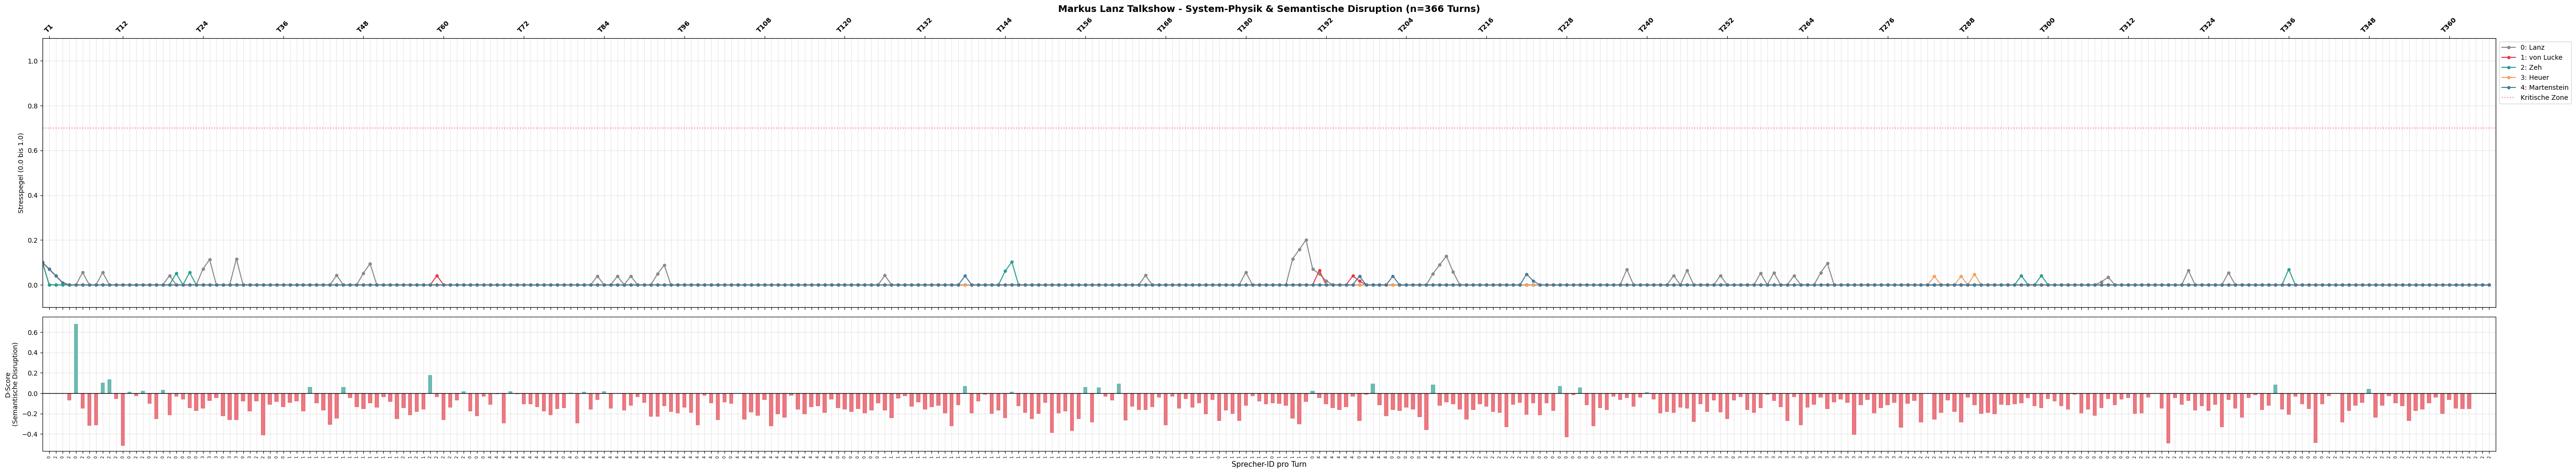

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import warnings

# Warnungen für die lineare Regression unterdrücken
warnings.filterwarnings("ignore")

# =====================================================================
# 0. KONFIGURATION (COLAB SCHALTER)
# =====================================================================
#@title ⚙️ Datei-Konfiguration
LADEN_VON_DRIVE = True #@param {type:"boolean"}
DRIVE_PFAD = "/content/drive/MyDrive/Colab Notebooks/Data/transkript-groß.csv" #@param {type:"string"}
LOKALER_PFAD = "transkript.csv"

print(f"🎙️ INITIALISIERE CO-PILOT V3 (INKL. DISRUPTIONS- & EMERGENZ-MODUL)...\n")

if LADEN_VON_DRIVE:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount('/content/drive')
    dateiname = DRIVE_PFAD
else:
    dateiname = LOKALER_PFAD

# =====================================================================
# 1. SETUP: PROFILE & MODELL (Markus Lanz vom 04.Juni 2026, erstellt von Gemini)
# =====================================================================
#names = ["Lanz", "von Lucke", "Zeh", "Heuer", "Martinstein"]
#
#profiles_data = [
#    [ 0.8,  0.5,  0.6,  0.2,  0.7,   0.5,  0.5,  0.9,   0.1, 0.0, 0.0], # Lanz
#    [ 0.5,  0.7,  0.8,  0.2,  0.8,   0.8,  0.3,  0.7,   0.1, 0.0, 0.0], # von Lucke
#    [ 0.7,  0.4,  0.4,  0.7,  0.6,   0.4,  0.7,  0.6,   0.1, 0.0, 0.0], # Zeh
#    [ 0.5,  0.6,  0.5,  0.5,  0.7,   0.6,  0.4,  0.6,   0.1, 0.0, 0.0], # Heuer
#    [ 0.6,  0.7,  0.8,  0.1,  0.5,   0.7,  0.6,  0.8,   0.1, 0.0, 0.0]  # Martinstein
#]
#
# =====================================================================
# 1. SETUP: PROFILE & MODELL (Markus Lanz vom 04. Juni 2025, erstellt von ChatGPT )
# =====================================================================
#
#names = ["Lanz", "von Lucke", "Zeh", "Heuer", "Martenstein"]
#
#profiles_data = [
    #        Big Five: E     A     C     N     O
    #        v-Memes:  Wahrheit   Identität   Freiheit
    #        Dynamik: unverändert
#    [ 0.85,  0.60,  0.55,  0.20,  0.80,   0.55,  0.45,  0.85,   0.10, 0.00, 0.00], # Lanz (Moderation & Pace-Keeper)
#    [ 0.55,  0.45,  0.85,  0.30,  0.85,   0.90,  0.40,  0.75,   0.10, 0.00, 0.00], # von Lucke (System-kritisch, analytischer Intellektueller)
#    [ 0.60,  0.75,  0.70,  0.35,  0.90,   0.80,  0.65,  0.75,   0.10, 0.00, 0.00], # Zeh (Pragmatisch, institutionell, faktenorientiert)
#    [ 0.55,  0.55,  0.80,  0.30,  0.90,   0.85,  0.65,  0.65,   0.10, 0.00, 0.00], # Heuer (Vergleichend, international, empirisch)
#    [ 0.50,  0.70,  0.65,  0.20,  0.75,   0.70,  0.60,  0.80,   0.10, 0.00, 0.00]  # Martenstein (Historisch-strukturell, nuanciert, souverän)
#]
names = ["Lanz", "von Lucke", "Zeh", "Heuer", "Martenstein"]

profiles_data = [
    [ 0.90,  0.55,  0.55,  0.20,  0.80,   0.60,  0.45,  0.85,   0.10, 0.00, 0.00], # Lanz
    [ 0.55,  0.40,  0.90,  0.30,  0.85,   0.95,  0.40,  0.70,   0.10, 0.00, 0.00], # von Lucke
    [ 0.60,  0.80,  0.70,  0.40,  0.90,   0.80,  0.75,  0.80,   0.10, 0.00, 0.00], # Zeh
    [ 0.60,  0.55,  0.80,  0.45,  0.90,   0.85,  0.60,  0.70,   0.10, 0.00, 0.00], # Heuer
    [ 0.65,  0.70,  0.70,  0.20,  0.85,   0.75,  0.75,  0.80,   0.10, 0.00, 0.00]  # Martenstein
]
#
# =====================================================================
# 1. SETUP: PROFILE & MODELL
# =====================================================================
#names = ["Lanz (Mod)", "Hübsch", "Khorchide", "Kayman", "Mansour"]
#Big Five mit niedrigerem Stresspegel: Markus Lanz vom 30.Mai 2024, erstellt von ChatGPT
#profiles_data = [
#    [ 0.6,  0.5,  0.4,  0.0,  0.7,   0.5,  0.5,  0.9,   0.1, 0.0, 0.0], # Lanz
#    [ 0.4,  0.6,  0.8,  0.5,  0.4,  -0.8,  0.9,  0.2,   0.1, 0.0, 0.0], # Hübsch
#    [ 0.6,  0.8,  0.4,  0.0,  0.4,   0.9, -0.2,  0.6,   0.1, 0.0, 0.0], # Khorchide
#    [ 0.7, -0.4,  0.8,  0.0,  0.7,   0.8, -0.5,  0.7,   0.1, 0.0, 0.0], # Kayman
#    [ 0.4,  0.5,  0.4,  0.2,  0.5,   0.9, -0.6,  0.8,   0.1, 0.0, 0.0]  # Mansour
#]
#Big Five mit höherem Stresspegel: Markus Lanz vom 30.Mai 2024, erstellt von Gemini
#profiles_data = [
#    [ 0.6,  0.5,  0.8, -0.4,  0.7,   0.5,  0.5,  0.9,   0.1, 0.0, 0.0],
#    [ 0.8, -0.6,  0.5,  0.8,  0.4,  -0.8,  0.9,  0.2,   0.1, 0.0, 0.0],
#    [ 0.4,  0.8,  0.7, -0.3,  0.8,   0.9, -0.2,  0.6,   0.1, 0.0, 0.0],
#    [ 0.5, -0.4,  0.8, -0.5,  0.6,   0.8, -0.5,  0.7,   0.1, 0.0, 0.0],
#    [ 0.9, -0.5,  0.6,  0.2,  0.8,   0.9, -0.6,  0.8,   0.1, 0.0, 0.0]
#]
profiles = torch.tensor(profiles_data, dtype=torch.float32)
state_tensor = profiles.clone()
current_task = torch.tensor([0.4, 0.3, 0.7, 0.8], dtype=torch.float32)

# =====================================================================
# 1B. PROFIL-ÜBERSICHT AUSGEBEN
# =====================================================================
print("=" * 75)
print("🧠 PSYCHOLOGISCHE PROFILE DER DISKUTANTEN (STARTBEDINGUNGEN)")
print("=" * 75)
print("Legende Persönlichkeit (Big Five):")
print("  [E]xtraversion, [A]greeableness (Verträglichkeit),")
print("  [C]onscientiousness (Gewissenhaftigkeit), [N]euroticism, [O]penness")
print("\nLegende Kernwerte (Values):")
print("  [V1] Wahrheit & Logik (Sachlicher Erkenntnisgewinn)")
print("  [V2] Identität & Loyalität (Verteidigung der eigenen Ingroup)")
print("  [V3] Freiheit & Aufklärung (Tabubruch, liberale Werte)")
print("-" * 75)

for i, name in enumerate(names):
    p = profiles_data[i]
    print(f"👤 {name.upper()}")
    print(f"   Big Five:  E: {p[0]:+.1f} | A: {p[1]:+.1f} | C: {p[2]:+.1f} | N: {p[3]:+.1f} | O: {p[4]:+.1f}")
    print(f"   Kernwerte: V1 (Wahrheit): {p[5]:+.1f} | V2 (Identität): {p[6]:+.1f} | V3 (Freiheit): {p[7]:+.1f}")
    print()
print("=" * 75 + "\n")

# =====================================================================
# 2. DATEN LADEN & VERARBEITEN
# =====================================================================
try:
    df = pd.read_csv(dateiname)
    print(f"✅ {len(df)} Redebeiträge erfolgreich aus '{dateiname}' geladen!\n")
except Exception as e:
    print(f"❌ Fehler beim Laden: {e}")
    df = pd.DataFrame([{"sp": 0, "tg": 1, "val": 0.0, "ar": 0.0, "text": "LEER"}])

num_turns = len(df)

# --- NEU: History Arrays für Stress UND Attention initialisieren ---
history_stress = np.zeros((num_turns + 1, 5))
history_stress[0] = state_tensor[:, 8].numpy()

history_attention = np.zeros((num_turns, 5)) # Speichert die echten Priority Scores

# =====================================================================
# 2B. MODUL 3: SEMANTISCHE DISRUPTION BERECHNEN
# =====================================================================
print("🧠 Berechne Semantische Disruption (Text-Embeddings)...")
try:
    from sentence_transformers import SentenceTransformer
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embedder.encode(df["text"].astype(str).tolist())
    print("✅ NLP-Modell geladen und Vektoren berechnet!")
except ImportError:
    print("⚠️ 'sentence-transformers' nicht installiert. Nutze Zufalls-Vektoren als Platzhalter.")
    embeddings = np.random.randn(num_turns, 384)

d_scores = np.zeros(num_turns)
k = 3 # Fenstergröße

def cos_sim(a, b):
    norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0: return 0.0
    return np.dot(a, b) / (norm_a * norm_b)

for t in range(num_turns):
    if t < k or t > num_turns - k - 1:
        d_scores[t] = 0.0
        continue

    past_vec = np.mean(embeddings[t-k:t], axis=0)
    curr_vec = embeddings[t]
    fut_vec = np.mean(embeddings[t+1:t+k+1], axis=0)

    sim_fut_curr = cos_sim(fut_vec, curr_vec)
    sim_fut_past = cos_sim(fut_vec, past_vec)

    d_scores[t] = sim_fut_curr - sim_fut_past

# =====================================================================
# 3. LIVE-MODERATION (Physik + Disruption Agent)
# =====================================================================
kompakte_zusammenfassung = []

print("\n" + "=" * 70)
print("🎬 STARTE SIMULATION")
print("=" * 70)

with torch.no_grad():
    for t, row in df.iterrows():
        sp, tg = int(row["sp"]), int(row["tg"])
        val, arousal = float(row["val"]), float(row["ar"])
        raw_text = str(row["text"])
        curr_d_score = d_scores[t]

        # --- A. PHYSIK-UPDATE ---
        state_tensor[sp, 9] += 0.45
        for i in range(5):
            if i != sp:
                state_tensor[i, 9] = max(0.0, state_tensor[i, 9] - 0.15)

        big5_diff = torch.norm(state_tensor[sp, 0:5] - state_tensor[tg, 0:5]).item()

        if val < -0.1:
            stress_impact = (arousal * 0.2) + (big5_diff * abs(val) * 0.1)
            state_tensor[tg, 8] += stress_impact
            state_tensor[sp, 8] = max(0.0, state_tensor[sp, 8] - 0.02)
            for i in range(5):
                if i != sp and i != tg:
                    state_tensor[i, 8] += arousal * 0.02
        elif val > 0.1:
            relief = val * 0.25
            state_tensor[tg, 8] = max(0.0, state_tensor[tg, 8] - relief)
            state_tensor[sp, 8] = max(0.0, state_tensor[sp, 8] - (relief * 0.5))
            for i in range(5):
                if i != sp and i != tg:
                    state_tensor[i, 8] = max(0.0, state_tensor[i, 8] - (relief * 0.3))
        else:
            state_tensor[tg, 8] = max(0.0, state_tensor[tg, 8] - 0.1)
            state_tensor[sp, 8] = max(0.0, state_tensor[sp, 8] - 0.1)

        for i in range(5):
            state_tensor[i, 8] = max(0.0, state_tensor[i, 8] - 0.03)

        state_tensor[:, 8:10] = torch.clamp(state_tensor[:, 8:10], 0.0, 1.0)
        history_stress[t+1] = state_tensor[:, 8].numpy()
        sys_energy = state_tensor[:, 8].sum().item()

        # --- B. KI-AGENT LOGIK ---
        try:
            attention = model(state_tensor, current_task, temperature=0.6)
            priority_scores = attention.sum(dim=0)
        except NameError:
            # Fallback, falls das NN-Modell nicht geladen ist
            priority_scores = torch.rand(5)

        priority_scores[sp] -= 1.0

        # --- NEU: Priority Scores für den Attention-Makrozustand speichern ---
        history_attention[t] = priority_scores.detach().cpu().numpy()

        agent_note = ""
        if sys_energy > 2.0 and curr_d_score < -0.02:
            agent_note = "🚨 STRESS-LOOP ERKANNT! Empfehle Themenwechsel."
            priority_scores[0] += 2.0
            priority_scores[2] += 1.0
        elif curr_d_score > 0.05:
            agent_note = "💡 DISRUPTION ERFOLGREICH! Thema neu gesetzt."

        best_next_speaker_idx = torch.argmax(priority_scores).item()

        d_label = "Disruptiv" if curr_d_score > 0 else "Konsolidierend"
        if t < k or t > num_turns - k - 1:
            d_label = "Initialisierung"

        print("-" * 75)
        print(f"🗣️ REALITÄT [{t+1}]: {names[sp]} (zu {names[tg]})")
        print(f"   \"{raw_text[:100]}...\"" if len(raw_text) > 100 else f"   \"{raw_text}\"")
        print(f"   🧠 Valenz: {val:+.2f} | D-Score: {curr_d_score:+.3f} ({d_label})")

        alert = "⚠️ KRITISCH" if sys_energy > 2.0 else "✅ Stabil"
        print(f"🤖 KI-CO-PILOT (Spg: {sys_energy:.2f} {alert}) | Empfehlung: >> {names[best_next_speaker_idx]} <<")
        if agent_note: print(f"   {agent_note}")

        kompakt_str = f"Turn {t+1:3} | Spg: {sys_energy:.2f} | D-Score: {curr_d_score:+.2f} | KI: >> {names[best_next_speaker_idx]} <<"
        kompakte_zusammenfassung.append(kompakt_str)

# =====================================================================
# 4. KOMPAKTE ZUSAMMENFASSUNG
# =====================================================================
print("\n" + "=" * 65)
print("📋 KOMPAKTE ZUSAMMENFASSUNG DES GESPRÄCHSVERLAUFS")
print("=" * 65)
for zeile in kompakte_zusammenfassung:
    print(zeile)
print("=" * 65 + "\n")

# =====================================================================
# 5. VISUALISIERUNG (FLEXIBILISIERT)
# =====================================================================
# Dynamische Plot-Breite für bessere Auflösung der x-Achse
fig_width = max(14, int(num_turns * 0.15))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_width, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
colors = ['#888888', '#e63946', '#2a9d8f', '#f4a261', '#457b9d']

for i in range(5):
    ax1.plot(range(num_turns + 1), history_stress[:, i], label=f"{i}: {names[i]}", color=colors[i], marker='.', linewidth=1.5, markersize=8)

ax1.set_title(f"Markus Lanz Talkshow - System-Physik & Semantische Disruption (n={num_turns} Turns)", fontweight='bold', fontsize=14)
ax1.set_ylabel("Stresspegel (0.0 bis 1.0)")
ax1.set_ylim(-0.1, 1.1)
ax1.axhline(y=0.7, color='red', linestyle=':', alpha=0.5, label='Kritische Zone')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True, alpha=0.3)

# Obere X-Achse dynamisch skalieren
ax1_top = ax1.twiny()
ax1_top.set_xlim(0, num_turns + 1)
tick_interval = max(1, num_turns // 30) # Passe das Intervall der Ticks an
x_ticks_top = [1] + list(range(tick_interval, num_turns + 1, tick_interval))
ax1_top.set_xticks(x_ticks_top)
ax1_top.set_xticklabels([f"T{t}" for t in x_ticks_top], fontsize=10, fontweight='bold', rotation=45)

# Unteres Panel
x_ticks_all = range(1, num_turns + 1)
x_labels = [str(int(row["sp"])) for t, row in df.iterrows()]
bar_colors = ['#2a9d8f' if d > 0 else '#e63946' for d in d_scores]
ax2.bar(x_ticks_all, d_scores, color=bar_colors, alpha=0.7, width=0.6)

ax2.set_xlabel("Sprecher-ID pro Turn", fontsize=11)
ax2.set_ylabel("D-Score\n(Semantische Disruption)")
ax2.axhline(y=0, color='black', linewidth=1)

# Dynamische Y-Achse für D-Score
d_min, d_max = np.min(d_scores), np.max(d_scores)
ax2.set_ylim(min(-0.05, d_min * 1.1), max(0.05, d_max * 1.1))

# Dynamische X-Ticks unten (verhindert Überlappung)
if num_turns > 100:
    ax2.set_xticks(x_ticks_all)
    ax2.set_xticklabels(x_labels, fontsize=6, rotation=90) # Kleinere Schrift + Rotation
else:
    ax2.set_xticks(x_ticks_all)
    ax2.set_xticklabels(x_labels, fontsize=8)

ax2.grid(True, axis='both', alpha=0.3)
ax1.set_xlim(0, num_turns + 1)
ax2.set_xlim(0, num_turns + 1)

plt.tight_layout()
plt.show()


🧠 ENTDECKUNG DER WAHREN UPSILON-MASCHINE (COLLECTIVE MIND)
🔬 Die Epsilon-Maschine hat 72 kausale Mikro-Zustände gefunden.
🌌 Die Upsilon-Maschine hat diese auf 3 Makro-Regime (den Collective Mind) komprimiert.


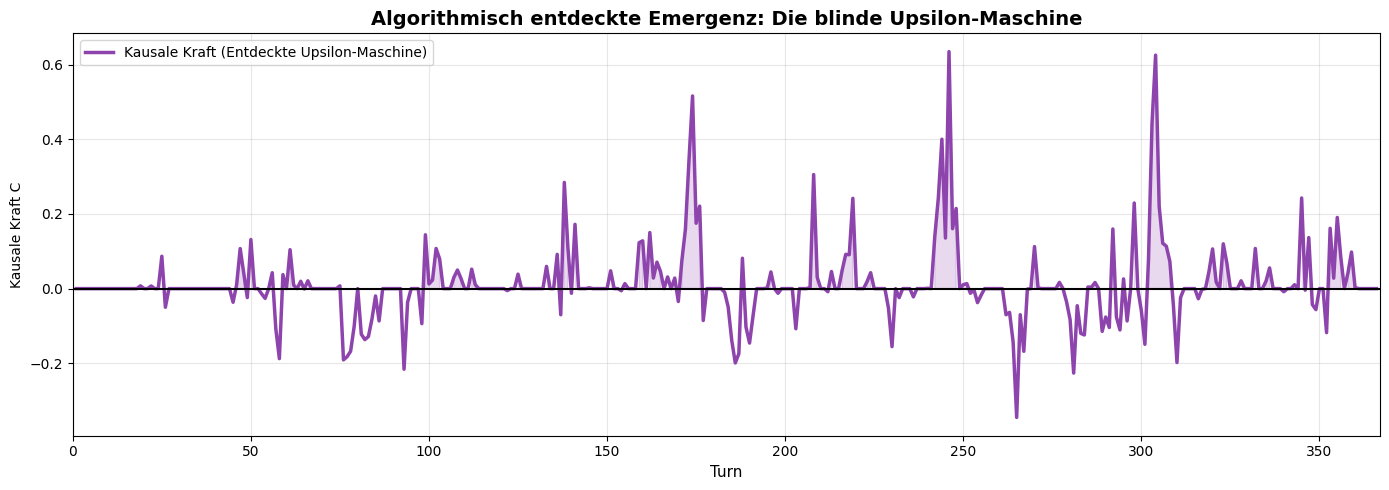

In [ ]:
# =====================================================================
# 9. ADD-ON: ALGORITHMISCHE ENTDECKUNG DER UPSILON-MASCHINE (KORRIGIERT)
# =====================================================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_regression

print("\n" + "=" * 70)
print("🧠 ENTDECKUNG DER WAHREN UPSILON-MASCHINE (COLLECTIVE MIND)")
print("=" * 70)

win = 8  # Beobachtungsfenster für die Vergangenheit
X_total = (d_scores + df["val"].values.astype(float)) / 2  # Reine Mikro-Daten

# Arrays für Machine Learning vorbereiten
X_features = np.zeros((num_turns - win, win))
Y_target = np.zeros(num_turns - win)

for t in range(win, num_turns):
    X_features[t-win] = X_total[t-win:t]
    Y_target[t-win] = X_total[t]

# ---------------------------------------------------------
# SCHRITT 1: DIE EPSILON-MASCHINE BAUT KAUSALE ZUSTÄNDE (Mikro)
# ---------------------------------------------------------
epsilon_machine = DecisionTreeRegressor(min_samples_leaf=4, random_state=42)
epsilon_machine.fit(X_features, Y_target)

# Jeder Turn wird nun einem "Leaf Node" zugewiesen (Kausale Mikro-Zustände)
causal_states_epsilon = epsilon_machine.apply(X_features)
print(f"🔬 Die Epsilon-Maschine hat {len(np.unique(causal_states_epsilon))} kausale Mikro-Zustände gefunden.")

# ---------------------------------------------------------
# SCHRITT 2: COARSE-GRAINING ZUR UPSILON-MASCHINE (Makro)
# ---------------------------------------------------------
predicted_futures = epsilon_machine.predict(X_features).reshape(-1, 1)

upsilon_machine = KMeans(n_clusters=3, random_state=42)
causal_states_upsilon = upsilon_machine.fit_predict(predicted_futures)
print(f"🌌 Die Upsilon-Maschine hat diese auf 3 Makro-Regime (den Collective Mind) komprimiert.")

# ---------------------------------------------------------
# SCHRITT 3: BEWEIS DER KAUSALEN KRAFT (C) DER ENTDECKTEN MASCHINE
# ---------------------------------------------------------
C_discovered = np.zeros(num_turns)
N_samples = len(causal_states_upsilon)

# i läuft nun sicher über die Indizes der berechneten Zustände (ohne Underflow)
for i in range(win, N_samples - 1):
    absolute_t = i + win # Der reale Turn-Index für das spätere Plot-Alignment

    # Makro-Dynamik der Upsilon-Maschine (Größe 'win')
    z_t = causal_states_upsilon[i - win : i].reshape(-1, 1)
    z_tp1 = causal_states_upsilon[i - win + 1 : i + 1]

    # Mikro-Dynamik der Rohdaten (letztes Feature im Zeitfenster)
    x_t = X_features[i - win : i, -1].reshape(-1, 1)
    x_tp1 = X_features[i - win + 1 : i + 1, -1]

    # Jitter hinzufügen, um Singularitäten bei identischen diskreten Werten zu vermeiden
    jitter_z = np.random.normal(0, 1e-5, z_t.shape)
    jitter_x = np.random.normal(0, 1e-5, x_t.shape)

    # Kausale Kraft C berechnen
    I_Z = mutual_info_regression(z_t + jitter_z, z_tp1.ravel())[0]
    I_X = mutual_info_regression(x_t + jitter_x, x_tp1.ravel())[0]

    C_discovered[absolute_t] = I_Z - I_X

# Visualisierung
fig_U, ax_U = plt.subplots(figsize=(14, 5))
ax_U.plot(range(1, num_turns + 1), C_discovered, color='#8e44ad', linewidth=2.5, label='Kausale Kraft (Entdeckte Upsilon-Maschine)')
ax_U.fill_between(range(1, num_turns + 1), C_discovered, 0, where=(C_discovered > 0), color='#8e44ad', alpha=0.2)
ax_U.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

ax_U.set_title("Algorithmisch entdeckte Emergenz: Die blinde Upsilon-Maschine", fontweight='bold', fontsize=14)
ax_U.set_xlabel("Turn", fontsize=11)
ax_U.set_ylabel("Kausale Kraft C")
ax_U.set_xlim(0, num_turns + 1)
ax_U.grid(True, alpha=0.3)
ax_U.legend()

plt.tight_layout()
plt.show()

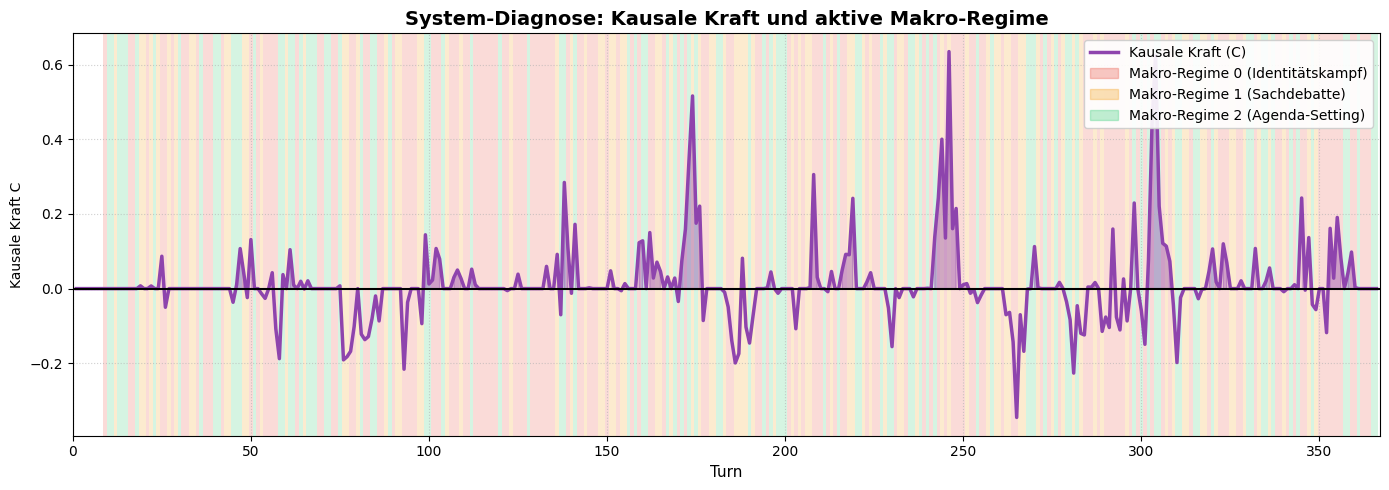

In [ ]:
import matplotlib.patches as mpatches

# =====================================================================
# NEUE VISUALISIERUNG: KAUSALE KRAFT + AKTIVE MAKRO-REGIME
# =====================================================================
fig_U, ax_U = plt.subplots(figsize=(14, 5))

# 1. Farben für die Makro-Regime definieren
# (Rot für Regime 0, Gelb für Regime 1, Grün für Regime 2 - anpassbar je nach Cluster-Bedeutung)
regime_colors = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}

# 2. Hintergründe basierend auf der Upsilon-Maschine (K-Means) einfärben
# causal_states_upsilon hat die Länge (num_turns - win). Wir mappen das auf die X-Achse.
for i, regime in enumerate(causal_states_upsilon):
    turn_x = i + win + 1 # +1 für das Alignment mit der 1-basierten Plot-Achse
    ax_U.axvspan(turn_x - 0.5, turn_x + 0.5, color=regime_colors[regime], alpha=0.2, lw=0)

# 3. Die Kausale Kraft plotten
ax_U.plot(range(1, num_turns + 1), C_discovered, color='#8e44ad', linewidth=2.5, label='Kausale Kraft (C)')

# 4. Den Bereich der Emergenz (C > 0) farblich ausfüllen
ax_U.fill_between(range(1, num_turns + 1), C_discovered, 0, where=(C_discovered > 0), color='#8e44ad', alpha=0.4)
ax_U.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# 5. Eigene Legende für die Regime erstellen
patch_0 = mpatches.Patch(color=regime_colors[0], alpha=0.3, label='Makro-Regime 0 (Identitätskampf)')
patch_1 = mpatches.Patch(color=regime_colors[1], alpha=0.3, label='Makro-Regime 1 (Sachdebatte)')
patch_2 = mpatches.Patch(color=regime_colors[2], alpha=0.3, label='Makro-Regime 2 (Agenda-Setting)')

# 6. Bestehende Legende erweitern
handles, labels = ax_U.get_legend_handles_labels()
handles.extend([patch_0, patch_1, patch_2])
ax_U.legend(handles=handles, loc='upper right', framealpha=0.9)

# 7. Achsen und Layout
ax_U.set_title("System-Diagnose: Kausale Kraft und aktive Makro-Regime", fontweight='bold', fontsize=14)
ax_U.set_xlabel("Turn", fontsize=11)
ax_U.set_ylabel("Kausale Kraft C")
ax_U.set_xlim(0, num_turns + 1)
ax_U.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

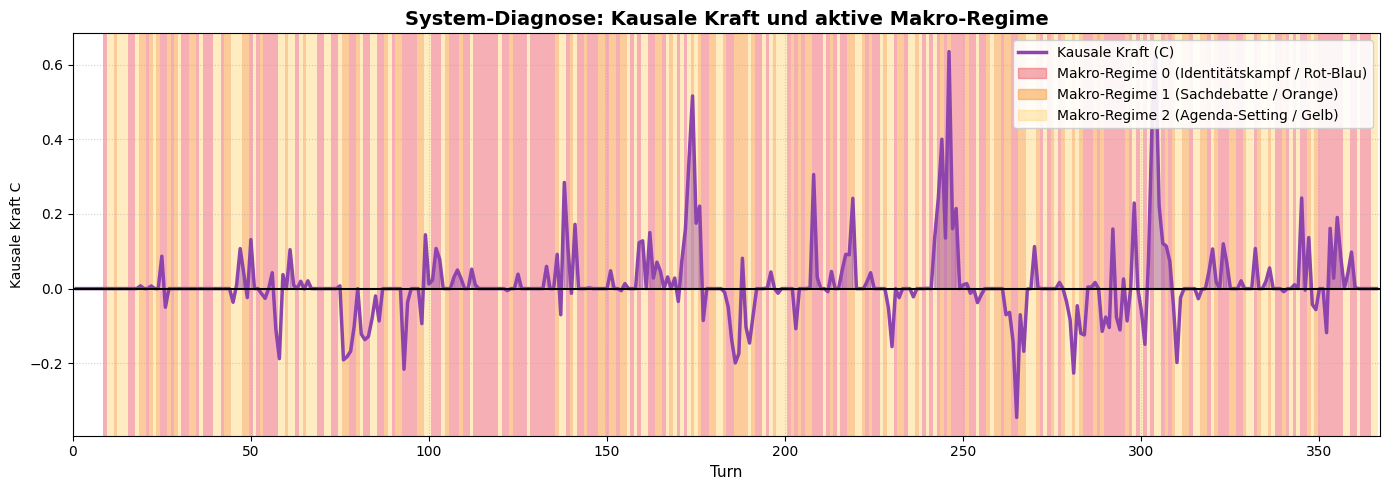

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =====================================================================
# NEUE VISUALISIERUNG: KAUSALE KRAFT + AKTIVE MAKRO-REGIME (Kräftigere Farben)
# =====================================================================
fig_U, ax_U = plt.subplots(figsize=(14, 5))

# 1. Farben für die Makro-Regime definieren (Kräftigere Spiral Dynamics Palette)
regime_colors = {
    0: '#e63946',  # ROT / BLAU (Identitätskampf)
    1: '#f77f00',  # ORANGE (Sachdebatte)
    2: '#ffd166'   # GELB (Agenda-Setting) - Etwas leuchtender für mehr Kontrast
}

# 2. Hintergründe basierend auf der Upsilon-Maschine (K-Means) einfärben
# Alpha-Wert von 0.2 auf 0.4 erhöht für kräftigere Farben
for i, regime in enumerate(causal_states_upsilon):
    turn_x = i + win + 1
    ax_U.axvspan(turn_x - 0.5, turn_x + 0.5, color=regime_colors[regime], alpha=0.4, lw=0)

# 3. Die Kausale Kraft plotten
ax_U.plot(range(1, num_turns + 1), C_discovered, color='#8e44ad', linewidth=2.5, label='Kausale Kraft (C)')

# 4. Den Bereich der Emergenz (C > 0) farblich ausfüllen
ax_U.fill_between(range(1, num_turns + 1), C_discovered, 0, where=(C_discovered > 0), color='#8e44ad', alpha=0.4)
ax_U.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# 5. Eigene Legende für die Regime erstellen (Alpha hier ebenfalls auf 0.4 anpassen)
patch_0 = mpatches.Patch(color=regime_colors[0], alpha=0.4, label='Makro-Regime 0 (Identitätskampf / Rot-Blau)')
patch_1 = mpatches.Patch(color=regime_colors[1], alpha=0.4, label='Makro-Regime 1 (Sachdebatte / Orange)')
patch_2 = mpatches.Patch(color=regime_colors[2], alpha=0.4, label='Makro-Regime 2 (Agenda-Setting / Gelb)')

# 6. Bestehende Legende erweitern
handles, labels = ax_U.get_legend_handles_labels()
handles.extend([patch_0, patch_1, patch_2])
ax_U.legend(handles=handles, loc='upper right', framealpha=0.9)

# 7. Achsen und Layout
ax_U.set_title("System-Diagnose: Kausale Kraft und aktive Makro-Regime", fontweight='bold', fontsize=14)
ax_U.set_xlabel("Turn", fontsize=11)
ax_U.set_ylabel("Kausale Kraft C")
ax_U.set_xlim(0, num_turns + 1)
ax_U.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

STARTE MASTER-VISUALISIERUNG: SOZIALE KOPPLUNG & HEATMAP...

🧠 Generiere automatische Themen-Vorschläge aus den Clustern...
🔍 Automatisch ermittelte Vorschläge:
   -> C1: Stimmung / Deutschland
   -> C2: Steht / England Migration
   -> C3: Wow / Schulen
   -> C4: Gesagt / Afd
--------------------------------------------------
✨ Manuelle Labels aktiv!


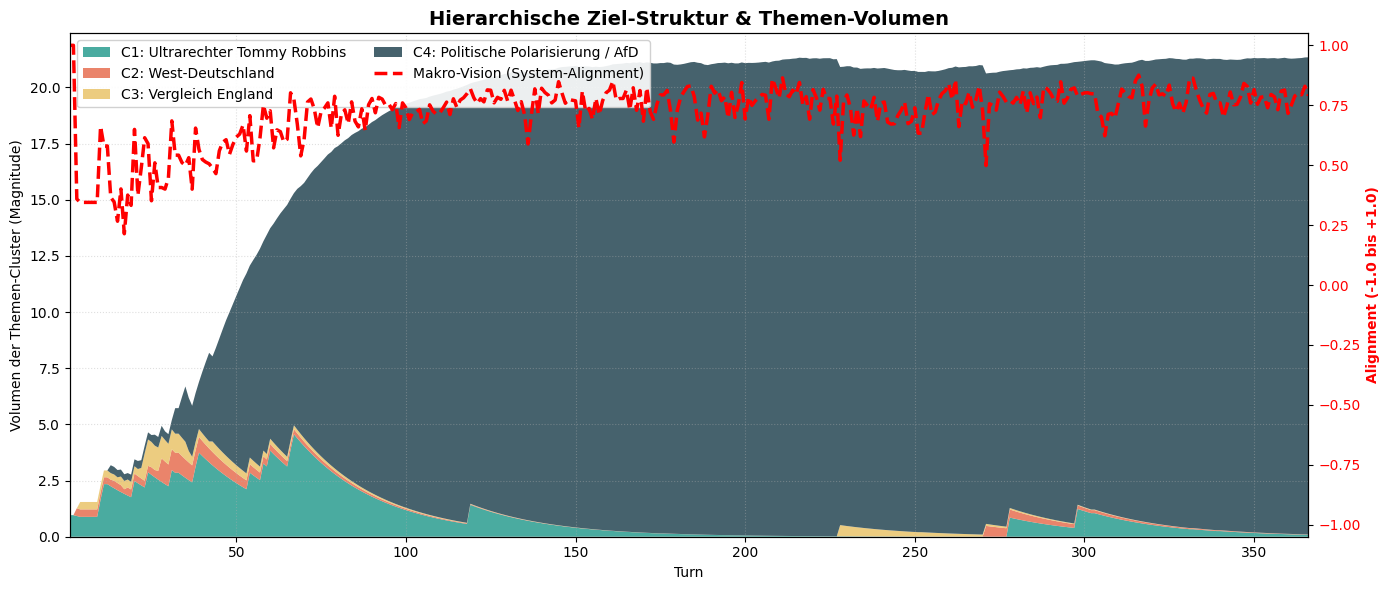

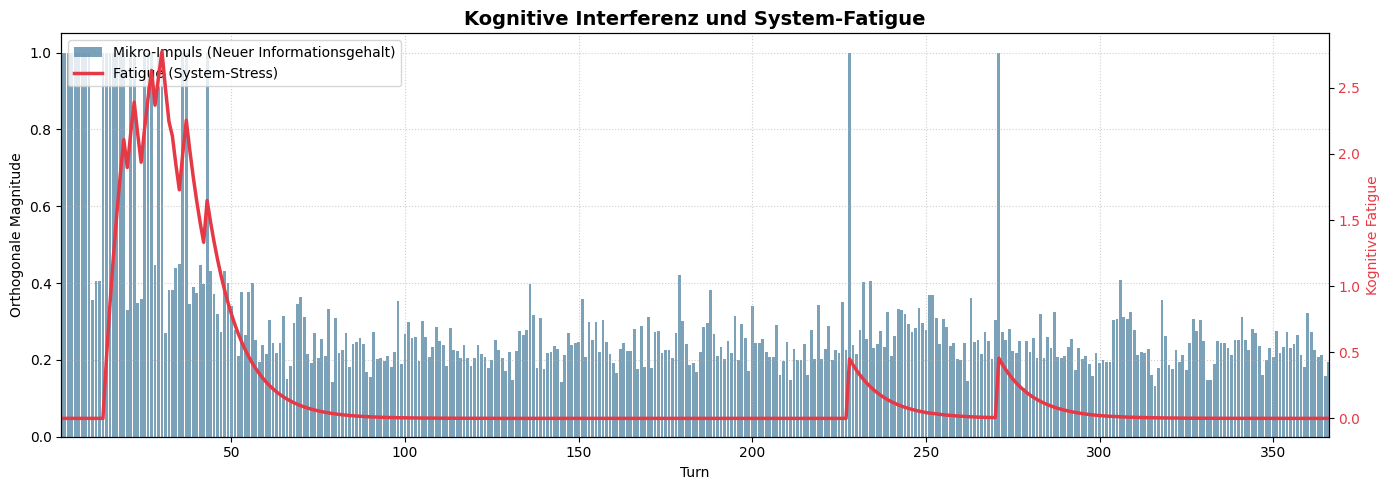

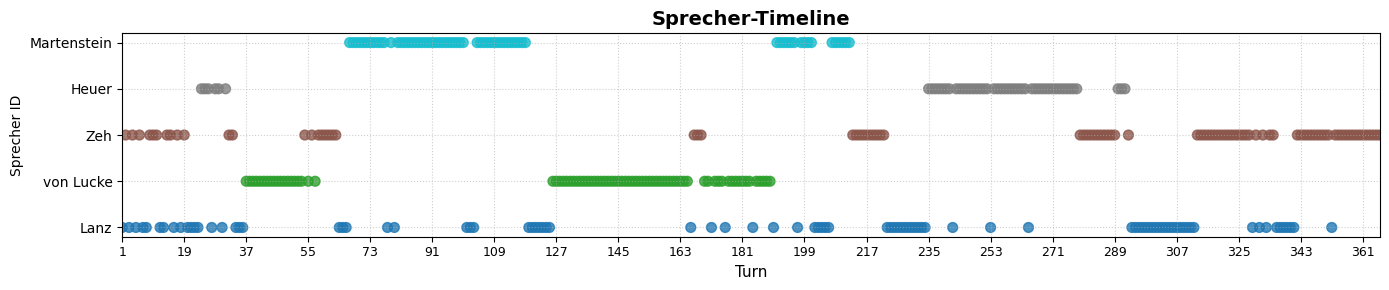

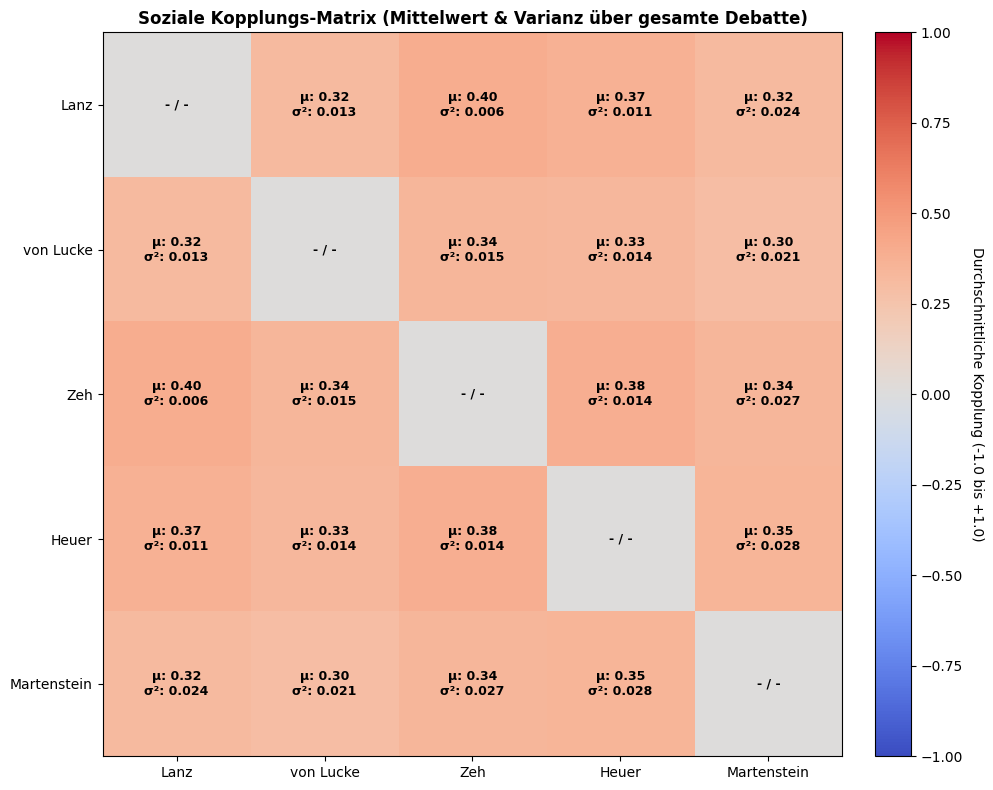

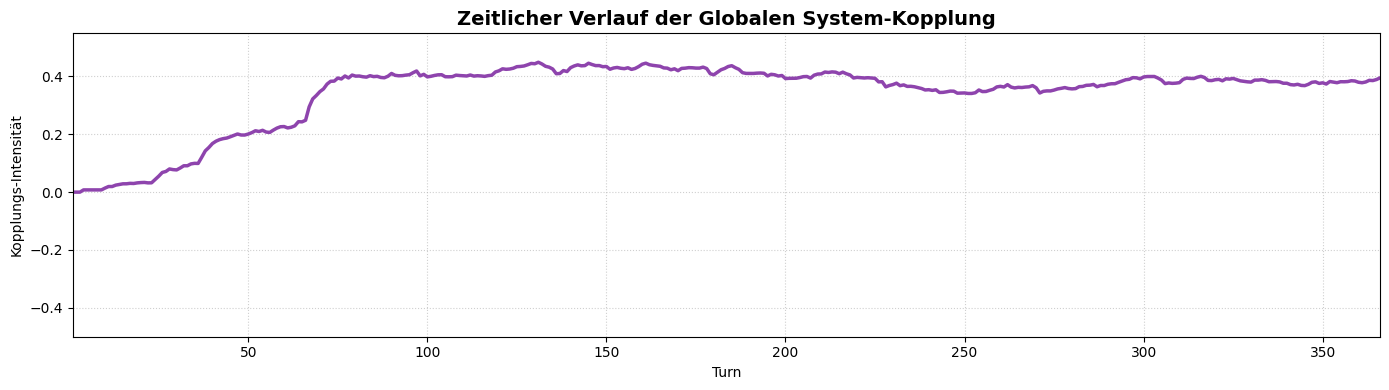


 Master-Visualisierung inkl. manuellem Override erfolgreich gerendert!


In [ ]:
# =====================================================================
# TEIL 2: HIERARCHISCHER J-SPACE MIT SPRECHER-KOPPLUNG & HEATMAP
# Inkl. automatischer Vorschläge und manuellem Themen-Override
# =====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings("ignore")
print("STARTE MASTER-VISUALISIERUNG: SOZIALE KOPPLUNG & HEATMAP...")

class HierarchicalJSpaceWithCoupling(nn.Module):
    def __init__(self, hidden_dim, num_speakers=5, num_meso_clusters=4, decay_rate=0.97):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_speakers = num_speakers
        self.num_meso = num_meso_clusters
        self.decay_rate = decay_rate

        self.macro_vision = None
        self.meso_centers = torch.zeros(self.num_meso, hidden_dim)
        self.meso_weights = torch.zeros(self.num_meso)
        self.active_clusters = 0

        self.speaker_coupling = torch.zeros(num_speakers, num_speakers)
        self.last_speaker_vectors = torch.zeros(num_speakers, hidden_dim)
        self.speaker_active_mask = torch.zeros(num_speakers, dtype=torch.bool)

    def forward(self, v_neu, speaker_id):
        v_neu = F.normalize(v_neu, p=2, dim=-1).squeeze(0)

        # 1. PHASEN-KOHÄRENZ & KOPPLUNG
        if torch.any(self.speaker_active_mask):
            active_indices = self.speaker_active_mask.nonzero(as_tuple=True)[0]
            for j in active_indices:
                if j.item() == speaker_id:
                    continue
                phase_alignment = torch.dot(v_neu, self.last_speaker_vectors[j]).item()
                self.speaker_coupling[speaker_id, j] = (
                    0.8 * self.speaker_coupling[speaker_id, j] + 0.2 * phase_alignment
                )
                self.speaker_coupling[j, speaker_id] = self.speaker_coupling[speaker_id, j]

        modulation = torch.zeros_like(v_neu)
        for j in range(self.num_speakers):
            if j != speaker_id and self.speaker_active_mask[j]:
                coupling = self.speaker_coupling[speaker_id, j]
                modulation += coupling * self.last_speaker_vectors[j]

        v_modulated = F.normalize(v_neu + 0.3 * modulation, p=2, dim=-1)

        self.last_speaker_vectors[speaker_id] = v_neu
        self.speaker_active_mask[speaker_id] = True

        # 2. MAKRO-VISION
        if self.macro_vision is None:
            self.macro_vision = v_modulated.clone()
        else:
            self.macro_vision = F.normalize(0.98 * self.macro_vision + 0.02 * v_modulated, p=2, dim=-1)

        macro_alignment = torch.dot(v_modulated, self.macro_vision).item()

        ortho_magnitude = 1.0
        fatigue_penalty = 0.0
        interference_type = "Orthogonal"

        # 3. MESO-CLUSTER INTERFERENZ
        if self.active_clusters == 0:
            self.meso_centers[0] = v_modulated
            self.meso_weights[0] = 1.0
            self.active_clusters = 1
        else:
            sims = torch.matmul(self.meso_centers[:self.active_clusters], v_modulated)
            best_sim, best_idx = torch.max(sims, dim=0)
            best_sim = best_sim.item()
            best_idx = best_idx.item()

            if best_sim > 0.55: # Konstruktiv
                self.meso_centers[best_idx] = F.normalize(0.85 * self.meso_centers[best_idx] + 0.15 * v_modulated, p=2, dim=-1)
                growth = 0.5 + (0.5 * max(0, macro_alignment))
                self.meso_weights[best_idx] += growth
                ortho_magnitude = 1.0 - best_sim
                interference_type = "Konstruktiv"

            elif best_sim < 0.15: # Destruktiv
                damage = (0.15 - best_sim) * 4.0
                self.meso_weights[best_idx] -= damage
                if self.meso_weights[best_idx] < 0:
                    self.meso_weights[best_idx] = 0.0
                ortho_magnitude = 1.0 - best_sim
                fatigue_penalty = damage * 0.5
                interference_type = "Destruktiv"

            else: # Orthogonal
                if self.active_clusters < self.num_meso:
                    self.meso_centers[self.active_clusters] = v_modulated
                    self.meso_weights[self.active_clusters] = max(0.2, macro_alignment)
                    self.active_clusters += 1
                else:
                    weakest_idx = torch.argmin(self.meso_weights).item()
                    self.meso_centers[weakest_idx] = v_modulated
                    self.meso_weights[weakest_idx] = max(0.2, macro_alignment)
                    fatigue_penalty = 0.5
                ortho_magnitude = 1.0

        self.meso_weights *= self.decay_rate
        return ortho_magnitude, macro_alignment, self.meso_weights.clone(), fatigue_penalty, interference_type


# =====================================================================
# SIMULATION DES GEKOPPELTEN BAUMES
# =====================================================================
NUM_MESO_CLUSTERS = 4
tree_space = HierarchicalJSpaceWithCoupling(hidden_dim=384, num_speakers=5, num_meso_clusters=NUM_MESO_CLUSTERS, decay_rate=0.96)

num_turns = len(df)
hist_ortho = np.zeros(num_turns)
hist_macro_align = np.zeros(num_turns)
hist_fatigue = np.zeros(num_turns)
hist_meso_weights = np.zeros((num_turns, NUM_MESO_CLUSTERS))
hist_global_coupling = np.zeros(num_turns)
hist_speaker_coupling = np.zeros((num_turns, 5, 5))
destructive_turns = []

speakers_array = df["sp"].astype(int).values
current_fatigue = 0.0

with torch.no_grad():
    for t in range(num_turns):
        text_content = str(df.iloc[t]["text"]).strip()
        sp_id = speakers_array[t]

        if len(text_content) < 15 and t > 0:
            hist_ortho[t] = hist_ortho[t-1]
            hist_macro_align[t] = hist_macro_align[t-1]
            hist_meso_weights[t] = hist_meso_weights[t-1]
            hist_global_coupling[t] = hist_global_coupling[t-1]
            hist_speaker_coupling[t] = hist_speaker_coupling[t-1]
            current_fatigue *= 0.95
            hist_fatigue[t] = current_fatigue
            continue

        input_vec = torch.tensor(embeddings[t], dtype=torch.float32).unsqueeze(0)
        ortho, align, weights, fatigue_pen, i_type = tree_space(input_vec, speaker_id=sp_id)

        hist_ortho[t] = ortho
        hist_macro_align[t] = align
        hist_meso_weights[t] = weights.numpy()

        current_fatigue = (current_fatigue + fatigue_pen) * 0.90
        hist_fatigue[t] = current_fatigue

        current_matrix = tree_space.speaker_coupling.numpy()
        mask = ~np.eye(current_matrix.shape[0], dtype=bool)
        hist_global_coupling[t] = np.mean(current_matrix[mask])
        hist_speaker_coupling[t] = current_matrix.copy()

        if i_type == "Destruktiv":
            destructive_turns.append((t, ortho))


# =====================================================================
# DYNAMISCHE THEMEN-EXTRAKTION (ALS REFERENZ / ERSTER LAUF)
# =====================================================================
print("\n🧠 Generiere automatische Themen-Vorschläge aus den Clustern...")
final_centers = tree_space.meso_centers.detach().numpy()
turn_assignments = []

for t in range(num_turns):
    vec = embeddings[t].reshape(1, -1)
    sims = cosine_similarity(vec, final_centers)[0]
    turn_assignments.append(np.argmax(sims))

df['cluster'] = turn_assignments

german_stopwords_extended = [
    'der', 'die', 'das', 'und', 'ist', 'in', 'zu', 'dass', 'es', 'nicht', 'ich', 'wir', 'sie', 'er', 'mit',
    'von', 'auf', 'für', 'ein', 'eine', 'auch', 'sich', 'den', 'dem', 'des', 'als', 'wie', 'da', 'dann',
    'aber', 'oder', 'was', 'wenn', 'so', 'aus', 'an', 'nach', 'im', 'man', 'hat', 'haben', 'sind', 'wird',
    'werden', 'war', 'ja', 'nein', 'mal', 'schon', 'gibt', 'mehr', 'immer', 'noch', 'nur', 'sehr', 'diese',
    'dieser', 'dieses', 'habe', 'hier', 'über', 'ganz', 'mich', 'mir', 'dir', 'uns', 'ihnen', 'ihr', 'zum',
    'zur', 'dazu', 'sagen', 'geht', 'müssen', 'machen', 'tun', 'vielleicht', 'einfach', 'jetzt', 'halt', 'weil',
    'okay', 'leute', 'glaube', 'glauben', 'wissen', 'viele', 'frage', 'thema', 'genau', 'richtig', 'gut',
    'bisschen', 'klar', 'natürlich', 'eigentlich', 'wirklich', 'gar', 'sicher', 'lassen', 'sehen', 'soll',
    'wollen', 'können', 'dürfen', 'wer', 'warum', 'wo', 'wann', 'denn', 'also', 'doch', 'eh', 'sogar',
    'wohl', 'quasi', 'irgendwie', 'wurde', 'worden', 'deren', 'dessen', 'davon', 'damit', 'darum', 'daran',
    'darauf', 'herr', 'frau', 'danke', 'bitte', 'gerade', 'heute', 'morgen', 'gestern', 'jahr', 'jahre',
    'jahren', 'zeit', 'fall', 'ab', 'ob', 'hin', 'her', 'dafür', 'dagegen', 'dabei', 'deswegen', 'nämlich',
    'lanz', 'lucke', 'zeh', 'heuer', 'martinstein', 'vom', 'beim', 'am'
]

auto_labels = []
for c_id in range(NUM_MESO_CLUSTERS):
    cluster_texts = df[df['cluster'] == c_id]['text'].astype(str).tolist()

    if len(cluster_texts) < 2:
        auto_labels.append(f"C{c_id+1}: Inaktiv")
        continue

    vectorizer = TfidfVectorizer(
        stop_words=german_stopwords_extended,
        max_df=0.7,
        min_df=1,
        ngram_range=(1, 2)
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        feature_names = vectorizer.get_feature_names_out()
        scores = tfidf_matrix.sum(axis=0).A1

        top_indices = scores.argsort()[::-1]
        top_words = []
        for idx in top_indices:
            word = feature_names[idx]
            if len(word) > 2:
                top_words.append(word.title())
            if len(top_words) == 2:
                break

        if top_words:
            auto_labels.append(f"C{c_id+1}: {' / '.join(top_words)}")
        else:
            auto_labels.append(f"C{c_id+1}: Divers")

    except ValueError:
        auto_labels.append(f"C{c_id+1}: Divers")

print("🔍 Automatisch ermittelte Vorschläge:")
for lbl in auto_labels:
    print(f"   -> {lbl}")
print("-" * 50)


# =====================================================================
# ⚙️ MANUELLER OVERRIDE (HIER LABELS BEI BEDARF ANPASSEN)
# =====================================================================
# Setze diesen Schalter auf True, um deine eigenen manuellen Labels zu nutzen:
AKTIVIERE_MANUELLEN_OVERRIDE = True

MANUELLE_LABELS_OVERRIDE = [
    "C1: Ultrarechter Tommy Robbins",
    "C2: West-Deutschland",
    "C3: Vergleich England",
    "C4: Politische Polarisierung / AfD"
]

if AKTIVIERE_MANUELLEN_OVERRIDE and len(MANUELLE_LABELS_OVERRIDE) == NUM_MESO_CLUSTERS:
    cluster_labels = MANUELLE_LABELS_OVERRIDE
    print("✨ Manuelle Labels aktiv!")
else:
    cluster_labels = auto_labels
    print("🤖 Nutze automatische Labels.")


# =====================================================================
# VISUALISIERUNG: GETRENNTE PLOTS FÜR DEN BLOG
# =====================================================================
base_colors = ['#2a9d8f', '#e76f51', '#e9c46a', '#264653', '#457b9d', '#8e44ad']
colors_meso = base_colors[:NUM_MESO_CLUSTERS]
x_axis = range(1, num_turns + 1)

# ---------------------------------------------------------
# PLOT 1: MESO-EBENE & MAKRO-VISION
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(14, 6))

ax1.stackplot(x_axis, hist_meso_weights.T, labels=cluster_labels, colors=colors_meso, alpha=0.85)
ax1.set_title("Hierarchische Ziel-Struktur & Themen-Volumen", fontweight='bold', fontsize=14)
ax1.set_ylabel("Volumen der Themen-Cluster (Magnitude)")
ax1.set_xlabel("Turn")
ax1.set_xlim(1, num_turns)
ax1.grid(True, linestyle=':', alpha=0.4)

ax1_twin = ax1.twinx()
ax1_twin.plot(x_axis, hist_macro_align, color='red', linestyle='--', linewidth=2.5, label='Makro-Vision (System-Alignment)')
ax1_twin.set_ylim(-1.05, 1.05)
ax1_twin.set_ylabel("Alignment (-1.0 bis +1.0)", color='red', fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor='red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9, ncol=2)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 2: MIKRO-EBENE & SYSTEM-STRESS
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 5))

ax2.bar(x_axis, hist_ortho, color='#457b9d', alpha=0.7, label='Mikro-Impuls (Neuer Informationsgehalt)')

for dt_turn, val in destructive_turns:
    ax2.axvline(x=dt_turn + 1, color='#e63946', linestyle='-', linewidth=2, alpha=0.8)
    if len(destructive_turns) > 0 and dt_turn == destructive_turns[0][0]:
        ax2.axvline(x=dt_turn + 1, color='#e63946', linestyle='-', linewidth=2, label='⚡ Destruktive Interferenz (Angriff)')

ax2.set_title("Kognitive Interferenz und System-Fatigue", fontweight='bold', fontsize=14)
ax2.set_ylabel("Orthogonale Magnitude")
ax2.set_xlabel("Turn")
ax2.set_xlim(1, num_turns)
ax2.grid(True, linestyle=':', alpha=0.6)

ax2_twin = ax2.twinx()
ax2_twin.plot(x_axis, hist_fatigue, color='#e63946', linewidth=2.5, label='Fatigue (System-Stress)')
ax2_twin.set_ylabel("Kognitive Fatigue", color='#e63946')
ax2_twin.tick_params(axis='y', labelcolor='#e63946')

lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 3: SPRECHER-VERTEILUNG (TIMELINE)
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(14, 3))

ax3.scatter(x_axis, speakers_array, c=speakers_array, cmap='tab10', s=50, alpha=0.8)
ax3.set_title("Sprecher-Timeline", fontweight='bold', fontsize=14)
ax3.set_ylabel("Sprecher ID")
ax3.set_yticks(range(5))

try:
    ax3.set_yticklabels(names)
except NameError:
    ax3.set_yticklabels([f"Sprecher {i}" for i in range(5)])

ax3.grid(True, linestyle=':', alpha=0.6)
ax3.set_xlabel("Turn", fontsize=11)
ax3.set_xlim(1, num_turns)

step_size = max(1, num_turns // 20)
tick_positions = list(range(1, num_turns + 1, step_size))
ax3.set_xticks(tick_positions)
ax3.set_xticklabels([str(t) for t in tick_positions], fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 4: SPRECHER-KOPPLUNGS-MATRIX (MITTELWERT & VARIANZ)
# ---------------------------------------------------------
fig4, ax_heat = plt.subplots(figsize=(10, 8))

mean_matrix = np.mean(hist_speaker_coupling, axis=0)
var_matrix = np.var(hist_speaker_coupling, axis=0)

im = ax_heat.imshow(mean_matrix, cmap='coolwarm', vmin=-1.0, vmax=1.0, aspect='auto')

ax_heat.set_xticks(range(5))
ax_heat.set_yticks(range(5))

try:
    ax_heat.set_xticklabels(names, fontsize=10)
    ax_heat.set_yticklabels(names, fontsize=10)
except NameError:
    pass

ax_heat.set_title("Soziale Kopplungs-Matrix (Mittelwert & Varianz über gesamte Debatte)", fontweight='bold', fontsize=12)

for i in range(5):
    for j in range(5):
        m_val = mean_matrix[i, j]
        v_val = var_matrix[i, j]

        if i == j:
            cell_text = "- / -"
            text_color = "black"
        else:
            cell_text = f"μ: {m_val:.2f}\nσ²: {v_val:.3f}"
            text_color = "white" if abs(m_val) > 0.5 else "black"

        ax_heat.text(j, i, cell_text, ha="center", va="center", color=text_color, fontweight='bold', fontsize=9)

cbar = fig4.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label('Durchschnittliche Kopplung (-1.0 bis +1.0)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 5: GLOBALE SYSTEM-KOPPLUNG (ZEITVERLAUF)
# ---------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(14, 4))

ax5.plot(x_axis, hist_global_coupling, color='#8e44ad', linewidth=2.5, label='Globale System-Kopplung (Mittelwert)')
ax5.set_title("Zeitlicher Verlauf der Globalen System-Kopplung", fontweight='bold', fontsize=14)
ax5.set_ylabel("Kopplungs-Intensität")
ax5.set_xlabel("Turn")
ax5.set_xlim(1, num_turns)
ax5.set_ylim(min(hist_global_coupling.min() - 0.1, -0.5), max(hist_global_coupling.max() + 0.1, 0.5))
ax5.grid(True, linestyle=':', alpha=0.6)

#marker_turn = min(88, num_turns // 2)
#ax5.axvline(x=marker_turn, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Turn {marker_turn} (Analyse-Fokus)')
#ax5.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("\n Master-Visualisierung inkl. manuellem Override erfolgreich gerendert!")

In [ ]:
# =====================================================================
# REINE J-SPACE NORDSTERN-EXTRAKTION
# =====================================================================
import torch
import torch.nn.functional as F

# 1. Den finalen Makro-Vision-Vektor aus dem J-Space holen (Shape: [384])
north_star_vec = tree_space.macro_vision.detach()

# 2. Alle im J-Space verarbeiteten Vektoren als Tensor
all_embeddings = torch.tensor(embeddings, dtype=torch.float32)

# 3. Kosinus-Ähnlichkeit des Nordsterns zu jedem einzelnen Turn im Raum berechnen
# (Da beide normalisiert sind, reicht das Skalarprodukt)
similarities = torch.matmul(all_embeddings, north_star_vec)

# 4. Finde den Turn mit der höchsten Übereinstimmung zum Nordstern-Vektor
best_match_idx = torch.argmax(similarities).item()
best_score = similarities[best_match_idx].item()

# 5. Ausgabe des mathematischen Kerns
matched_speaker = names[int(df.iloc[best_match_idx]["sp"])]
matched_text = df.iloc[best_match_idx]["text"]

print("="*60)
print("🧭 DER MATHEMATISCHE NORDSTERN IM J-SPACE:")
print("="*60)
print(f"Ähnlichkeits-Score zum Gravitationszentrum: {best_score:.4f}")
print(f"Repräsentativer Impuls (Turn {best_match_idx + 1} durch {matched_speaker}):")
print(f"\"{matched_text}\"\n")

🧭 DER MATHEMATISCHE NORDSTERN IM J-SPACE:
Ähnlichkeits-Score zum Gravitationszentrum: 0.7699
Repräsentativer Impuls (Turn 316 durch Zeh):
"Da hört auch keiner mehr hin und nimmt es nicht ernst."



In [ ]:
# =====================================================================
# INHALTLICHE ENTLÜFTUNG DER MESO-CLUSTER (TOPIC EXTRACTION)
# =====================================================================
import torch
import numpy as np

print("🔍 ANALYSIERE DEN INHALT DER 4 MESO-CLUSTER...\n")

# Wir holen uns die Zentren der Cluster (Form: [4, 384])
centers = tree_space.meso_centers[:tree_space.active_clusters].detach()
embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)

cluster_names = {}

for idx, center in enumerate(centers):
    # Kosinus-Ähnlichkeit zwischen Cluster-Zentrum und allen Sätzen im Transkript
    sims = torch.matmul(embeddings_tensor, center) / (torch.norm(embeddings_tensor, dim=1) * torch.norm(center) + 1e-8)

    # Finde die Top 3 repräsentativsten Sätze für dieses Cluster
    top_indices = torch.argsort(sims, descending=True)[:3].numpy()

    print(f"--------------------------------------------------")
    print(f"📌 THEMEN-CLUSTER {idx + 1} (Farbe im Plot)")
    print(f"--------------------------------------------------")
    for i in top_indices:
        sp_id = int(df.iloc[i]["sp"])
        speaker_name = names[sp_id]
        text_snippet = df.iloc[i]["text"]
        score = sims[i].item()
        print(f"  • [Ähnlichkeit: {score:.2f}] {speaker_name} (Turn {i+1}):")
        print(f"    \"{text_snippet}\"\n")

🔍 ANALYSIERE DEN INHALT DER 4 MESO-CLUSTER...

--------------------------------------------------
📌 THEMEN-CLUSTER 1 (Farbe im Plot)
--------------------------------------------------
  • [Ähnlichkeit: 0.87] Heuer (Turn 278):
    " Man merkt sozusagen, da sind wir wieder beim Stimmungsbild, dass sich das wirklich aufgeheizt hat."

  • [Ähnlichkeit: 0.85] Martenstein (Turn 67):
    " Ja, also bei mir ist die Stimmung auch nicht besser als bei den anderen."

  • [Ähnlichkeit: 0.85] Lanz (Turn 20):
    " Nein, aber die Stimmung ist jetzt auch hier scheiße, muss man sagen."

--------------------------------------------------
📌 THEMEN-CLUSTER 2 (Farbe im Plot)
--------------------------------------------------
  • [Ähnlichkeit: 0.97] Heuer (Turn 271):
    " Also nicht in London, sondern in Norfolk."

  • [Ähnlichkeit: 0.49] Lanz (Turn 232):
    "In England ist es Migration."

  • [Ähnlichkeit: 0.47] Zeh (Turn 316):
    "Da hört auch keiner mehr hin und nimmt es nicht ernst."

--------------

🚀 STARTE DELTA-SYNTHESE (GEKOPPELT AN UPSILON-MASCHINE)...

🔬 ÜBEREINSTIMMUNG (Delta-Impulse vs. Upsilon-Regime): 0.0006
📊 Analysierte Gesamtlänge: 366 Turns (Offset: 8)



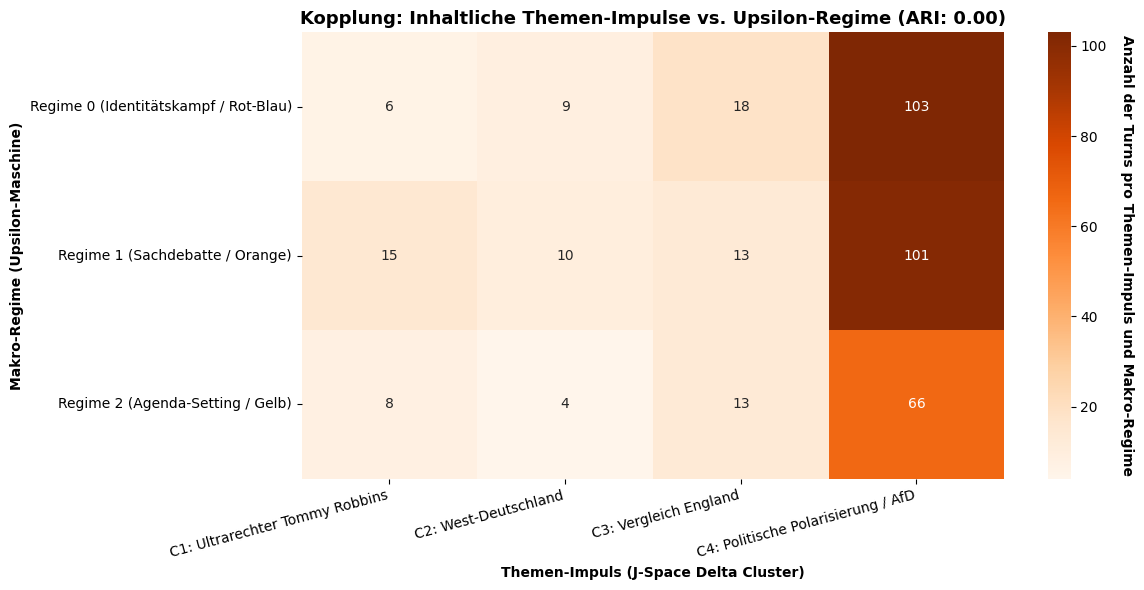

In [ ]:
# =====================================================================
# DELTA-SYNTHESE: J-SPACE IMPULSE VS. UPSILON-MASCHINE (GEFIXT)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

print("🚀 STARTE DELTA-SYNTHESE (GEKOPPELT AN UPSILON-MASCHINE)...\n")

num_turns = len(hist_meso_weights)

# 1. Delta-Zuwachs der J-Space Cluster berechnen
delta_weights = np.vstack((hist_meso_weights[0], np.diff(hist_meso_weights, axis=0)))
j_space_delta_clusters = np.argmax(delta_weights, axis=1)

# 2. Direkter Abgriff der Kausalen Emergenz (Upsilon-Maschine)
causal_emergence_clusters = np.full(num_turns, 1, dtype=int) # Default auf Regime 1

try:
    current_win = win
except NameError:
    current_win = 3 # Fallback, falls win nicht definiert ist

for i, regime in enumerate(causal_states_upsilon):
    idx = i + current_win
    if idx < num_turns:
        causal_emergence_clusters[idx] = int(regime)

# 3. Mathematische Übereinstimmung (ARI) berechnen
ari_score_delta = adjusted_rand_score(causal_emergence_clusters, j_space_delta_clusters)

print("="*60)
print(f"🔬 ÜBEREINSTIMMUNG (Delta-Impulse vs. Upsilon-Regime): {ari_score_delta:.4f}")
print(f"📊 Analysierte Gesamtlänge: {num_turns} Turns (Offset: {current_win})")
print("="*60 + "\n")

# 4. Asymmetrische Wahrheitsmatrix (Contingency Matrix) sicher berechnen
unique_regimes = sorted(list(set(causal_emergence_clusters)))

# Wir erzwingen eine Matrix der Größe: (Anzahl aktive Regime) x (Anzahl Meso-Cluster)
conf_matrix_delta = np.zeros((len(unique_regimes), NUM_MESO_CLUSTERS), dtype=int)

for r_idx, regime_val in enumerate(unique_regimes):
    for c_idx in range(NUM_MESO_CLUSTERS):
        conf_matrix_delta[r_idx, c_idx] = np.sum(
            (causal_emergence_clusters == regime_val) &
            (j_space_delta_clusters == c_idx)
        )

# Dynamische Labels passend zur Upsilon-Maschine
all_regime_labels = [
    'Regime 0 (Identitätskampf / Rot-Blau)',
    'Regime 1 (Sachdebatte / Orange)',
    'Regime 2 (Agenda-Setting / Gelb)'
]
active_regime_labels = [all_regime_labels[r] for r in unique_regimes]
x_labels_dynamic = cluster_labels[:NUM_MESO_CLUSTERS]

plt.figure(figsize=(12, 6)) # Leicht verbreitert für 4 Spalten

ax = sns.heatmap(
    conf_matrix_delta,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=x_labels_dynamic,
    yticklabels=active_regime_labels
)

cbar = ax.collections[0].colorbar
cbar.set_label('Anzahl der Turns pro Themen-Impuls und Makro-Regime', fontweight='bold', rotation=270, labelpad=20)

plt.title(f'Kopplung: Inhaltliche Themen-Impulse vs. Upsilon-Regime (ARI: {ari_score_delta:.2f})', fontweight='bold', fontsize=13)
plt.xlabel('Themen-Impuls (J-Space Delta Cluster)', fontweight='bold')
plt.ylabel('Makro-Regime (Upsilon-Maschine)', fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

⚡ BERECHNUNG DES DISKURS-PHASENÜBERGANGS (AGGREGATOR VS. DIFFERENTIATOR)...
🧭 ERMITTELTE UMSCHLAGPUNKTE (Reibung -> Konsolidierung):
Turn 65: Sprung zur Konsolidierung (Index-Sprung von 47.04 auf 99.82)
Turn 78: Sprung zur Konsolidierung (Index-Sprung von 51.31 auf 121.47)
Turn 98: Sprung zur Konsolidierung (Index-Sprung von 54.02 auf 101.73)
Turn 130: Sprung zur Konsolidierung (Index-Sprung von 93.58 auf 139.48)
Turn 137: Sprung zur Konsolidierung (Index-Sprung von 65.23 auf 114.76)
Turn 139: Sprung zur Konsolidierung (Index-Sprung von 67.16 auf 116.93)
Turn 144: Sprung zur Konsolidierung (Index-Sprung von 91.12 auf 147.32)
Turn 151: Sprung zur Konsolidierung (Index-Sprung von 58.31 auf 101.07)
Turn 166: Sprung zur Konsolidierung (Index-Sprung von 75.32 auf 119.91)
Turn 168: Sprung zur Konsolidierung (Index-Sprung von 73.19 auf 116.74)
Turn 170: Sprung zur Konsolidierung (Index-Sprung von 67.65 auf 118.54)
Turn 195: Sprung zur Konsolidierung (Index-Sprung von 67.15 auf 105.41)
Turn 19

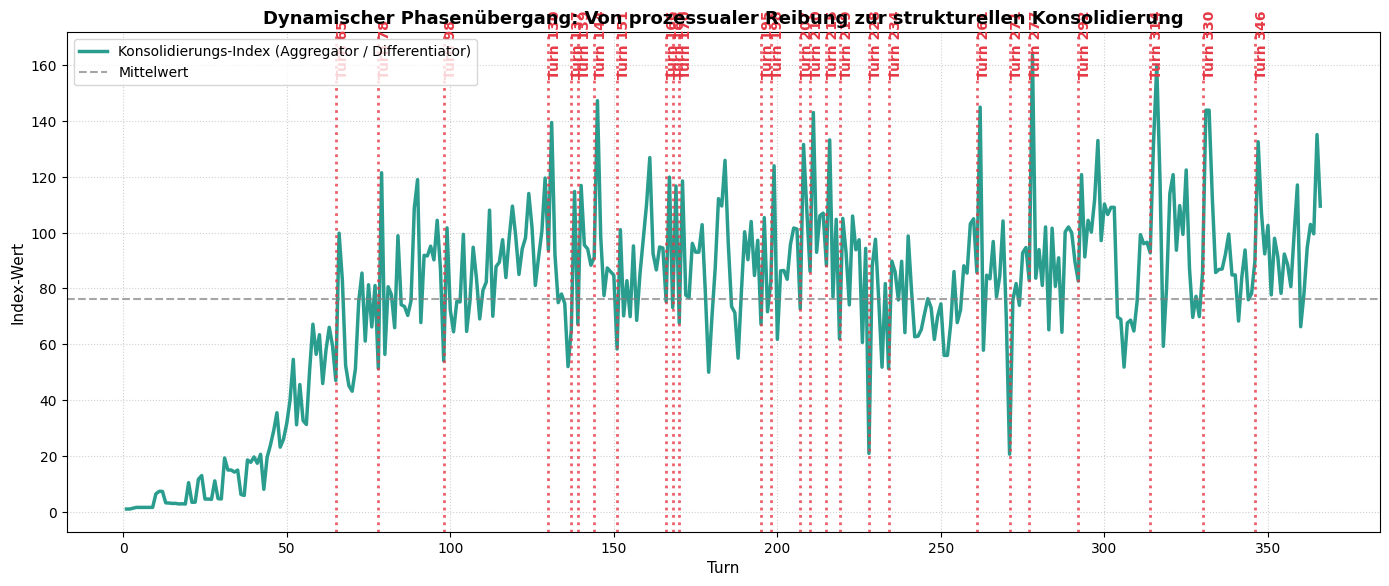

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("⚡ BERECHNUNG DES DISKURS-PHASENÜBERGANGS (AGGREGATOR VS. DIFFERENTIATOR)...")

# 1. Proxies aus dem J-Space-Modell ableiten:
# - Aggregator-Proxy: Die Summe der aktiven Meso-Gewichte (Konsolidierung / capacity_share)
# - Differentiator-Proxy: Die orthogonale Magnitude / Mikro-Impulse (Reibung / transport in flight)
aggregator_proxy = np.sum(hist_meso_weights, axis=1)
differentiator_proxy = hist_ortho

# 2. Konsolidierungs-Index berechnen (Verhältnis von Struktur-Aufbau zu Reibung)
epsilon = 1e-5
consolidation_index = aggregator_proxy / (differentiator_proxy + epsilon)

# 3. Umschlagpunkte (Phase Transitions) identifizieren:
# Wo steigt der Index sprunghaft an? (Wechsel von reiner Reibung zu stabiler Konsolidierung)
index_diff = np.diff(consolidation_index)
threshold = np.mean(index_diff) + 1.5 * np.std(index_diff)
transition_turns = np.where(index_diff > threshold)[0] + 1

print("="*60)
print("🧭 ERMITTELTE UMSCHLAGPUNKTE (Reibung -> Konsolidierung):")
print("="*60)
for t in transition_turns:
    print(f"Turn {t}: Sprung zur Konsolidierung (Index-Sprung von {consolidation_index[t-1]:.2f} auf {consolidation_index[t]:.2f})")

# 4. Visualisierung des Phasenübergangs
plt.figure(figsize=(14, 6))
plt.plot(range(1, num_turns + 1), consolidation_index, color='#2a9d8f', linewidth=2.5, label='Konsolidierungs-Index (Aggregator / Differentiator)')
plt.axhline(y=np.mean(consolidation_index), color='gray', linestyle='--', alpha=0.7, label='Mittelwert')

for t in transition_turns:
    plt.axvline(x=t, color='#e63946', linestyle=':', alpha=0.8, linewidth=2)
    plt.text(t, plt.ylim()[1] * 0.9, f' Turn {t}', color='#e63946', fontweight='bold', rotation=90)

plt.title('Dynamischer Phasenübergang: Von prozessualer Reibung zur strukturellen Konsolidierung', fontweight='bold', fontsize=13)
plt.xlabel('Turn', fontsize=11)
plt.ylabel('Index-Wert', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

🎯 SPRECHER-ANALYSE DER STRUCTURAL CONSOLIDATION POINTS:
📍 TURN  65 | Sprecher: Lanz         | Index-Sprung: 59.47 ➔ 47.04
   Aussage: "Da kommen wir gleich dazu."

📍 TURN  78 | Sprecher: Lanz         | Index-Sprung: 81.05 ➔ 51.31
   Aussage: "Weil sie zu 30 Prozent die CDU und zu 20 Prozent die AfD gewählt haben."

📍 TURN  98 | Sprecher: Martenstein  | Index-Sprung: 86.93 ➔ 54.02
   Aussage: " Und deswegen, ich glaube, dass wir vielleicht uns, und das hört man ziemlich of..."

📍 TURN 130 | Sprecher: von Lucke    | Index-Sprung: 119.59 ➔ 93.58
   Aussage: "Wenn es so einfach wäre."

📍 TURN 137 | Sprecher: von Lucke    | Index-Sprung: 52.01 ➔ 65.23
   Aussage: " Und würde, wenn Sie das, wenn Sie das, deswegen können Sie doch, deswegen könne..."

📍 TURN 139 | Sprecher: von Lucke    | Index-Sprung: 114.76 ➔ 67.16
   Aussage: " Sie suggerieren so, als wäre das eine ganz leichte Arithmetik, bei der man quas..."

📍 TURN 144 | Sprecher: von Lucke    | Index-Sprung: 88.34 ➔ 91.12
   Aussage: " 

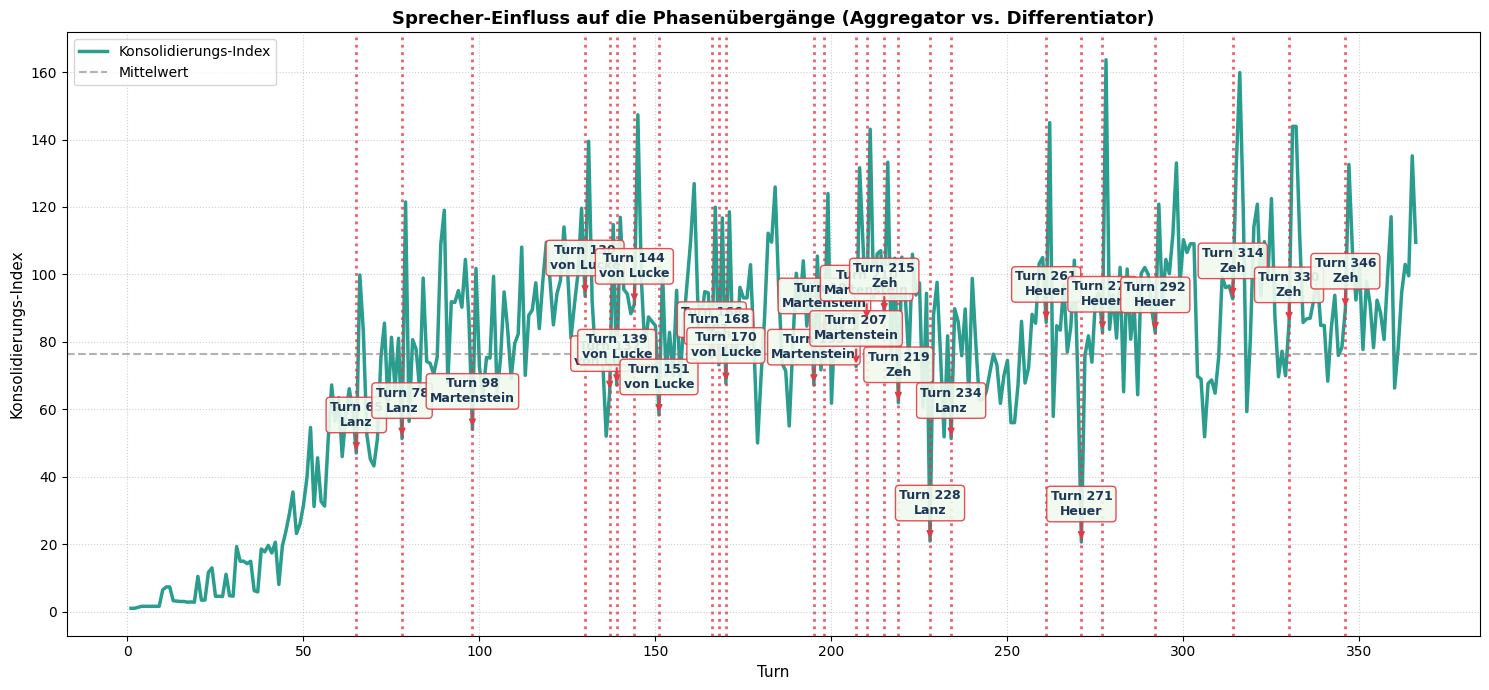

In [ ]:
# =====================================================================
# SPRECHER-ZUORDNUNG DER PHASENÜBERGÄNGE
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*65)
print("🎯 SPRECHER-ANALYSE DER STRUCTURAL CONSOLIDATION POINTS:")
print("="*65)

# 1. Daten der Umschlagpunkte extrahieren
transition_details = []

for t in transition_turns:
    # Index im DataFrame (0-basiert)
    idx = t - 1
    speaker_id = int(df.iloc[idx]["sp"])
    speaker_name = names[speaker_id]
    turn_text = df.iloc[idx]["text"]

    # Text einkürzen für bessere Lesbarkeit
    short_text = turn_text[:80] + "..." if len(turn_text) > 80 else turn_text

    prev_idx = consolidation_index[idx - 1]
    curr_idx = consolidation_index[idx]

    transition_details.append({
        'turn': t,
        'speaker': speaker_name,
        'jump': f"{prev_idx:.2f} ➔ {curr_idx:.2f}",
        'text': turn_text
    })

    print(f"📍 TURN {t:3d} | Sprecher: {speaker_name:<12} | Index-Sprung: {prev_idx:5.2f} ➔ {curr_idx:5.2f}")
    print(f"   Aussage: \"{short_text}\"\n")

# 2. Erweiterter Plot mit Sprecher-Labels
plt.figure(figsize=(15, 7))
plt.plot(range(1, num_turns + 1), consolidation_index, color='#2a9d8f', linewidth=2.5, label='Konsolidierungs-Index')
plt.axhline(y=np.mean(consolidation_index), color='gray', linestyle='--', alpha=0.6, label='Mittelwert')

# Annotations für die Sprecher setzen
for item in transition_details:
    t = item['turn']
    sp = item['speaker']
    y_val = consolidation_index[t-1]

    plt.axvline(x=t, color='#e63946', linestyle=':', alpha=0.8, linewidth=2)
    plt.annotate(f"Turn {t}\n{sp}",
                 xy=(t, y_val),
                 xytext=(t, y_val + 8),
                 fontweight='bold',
                 fontsize=9,
                 color='#1d3557',
                 ha='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#f1faee', edgecolor='#e63946', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='#e63946', lw=1.5))

plt.title('Sprecher-Einfluss auf die Phasenübergänge (Aggregator vs. Differentiator)', fontweight='bold', fontsize=13)
plt.xlabel('Turn', fontsize=11)
plt.ylabel('Konsolidierungs-Index', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


⚛️ BERECHNE PARISI-THERMODYNAMIK MIT DYNAMISCHEN SCHWELLENWERTEN
🎯 Dynamisch kalibrierte kritische Energiegrenze (E_crit): -2.233


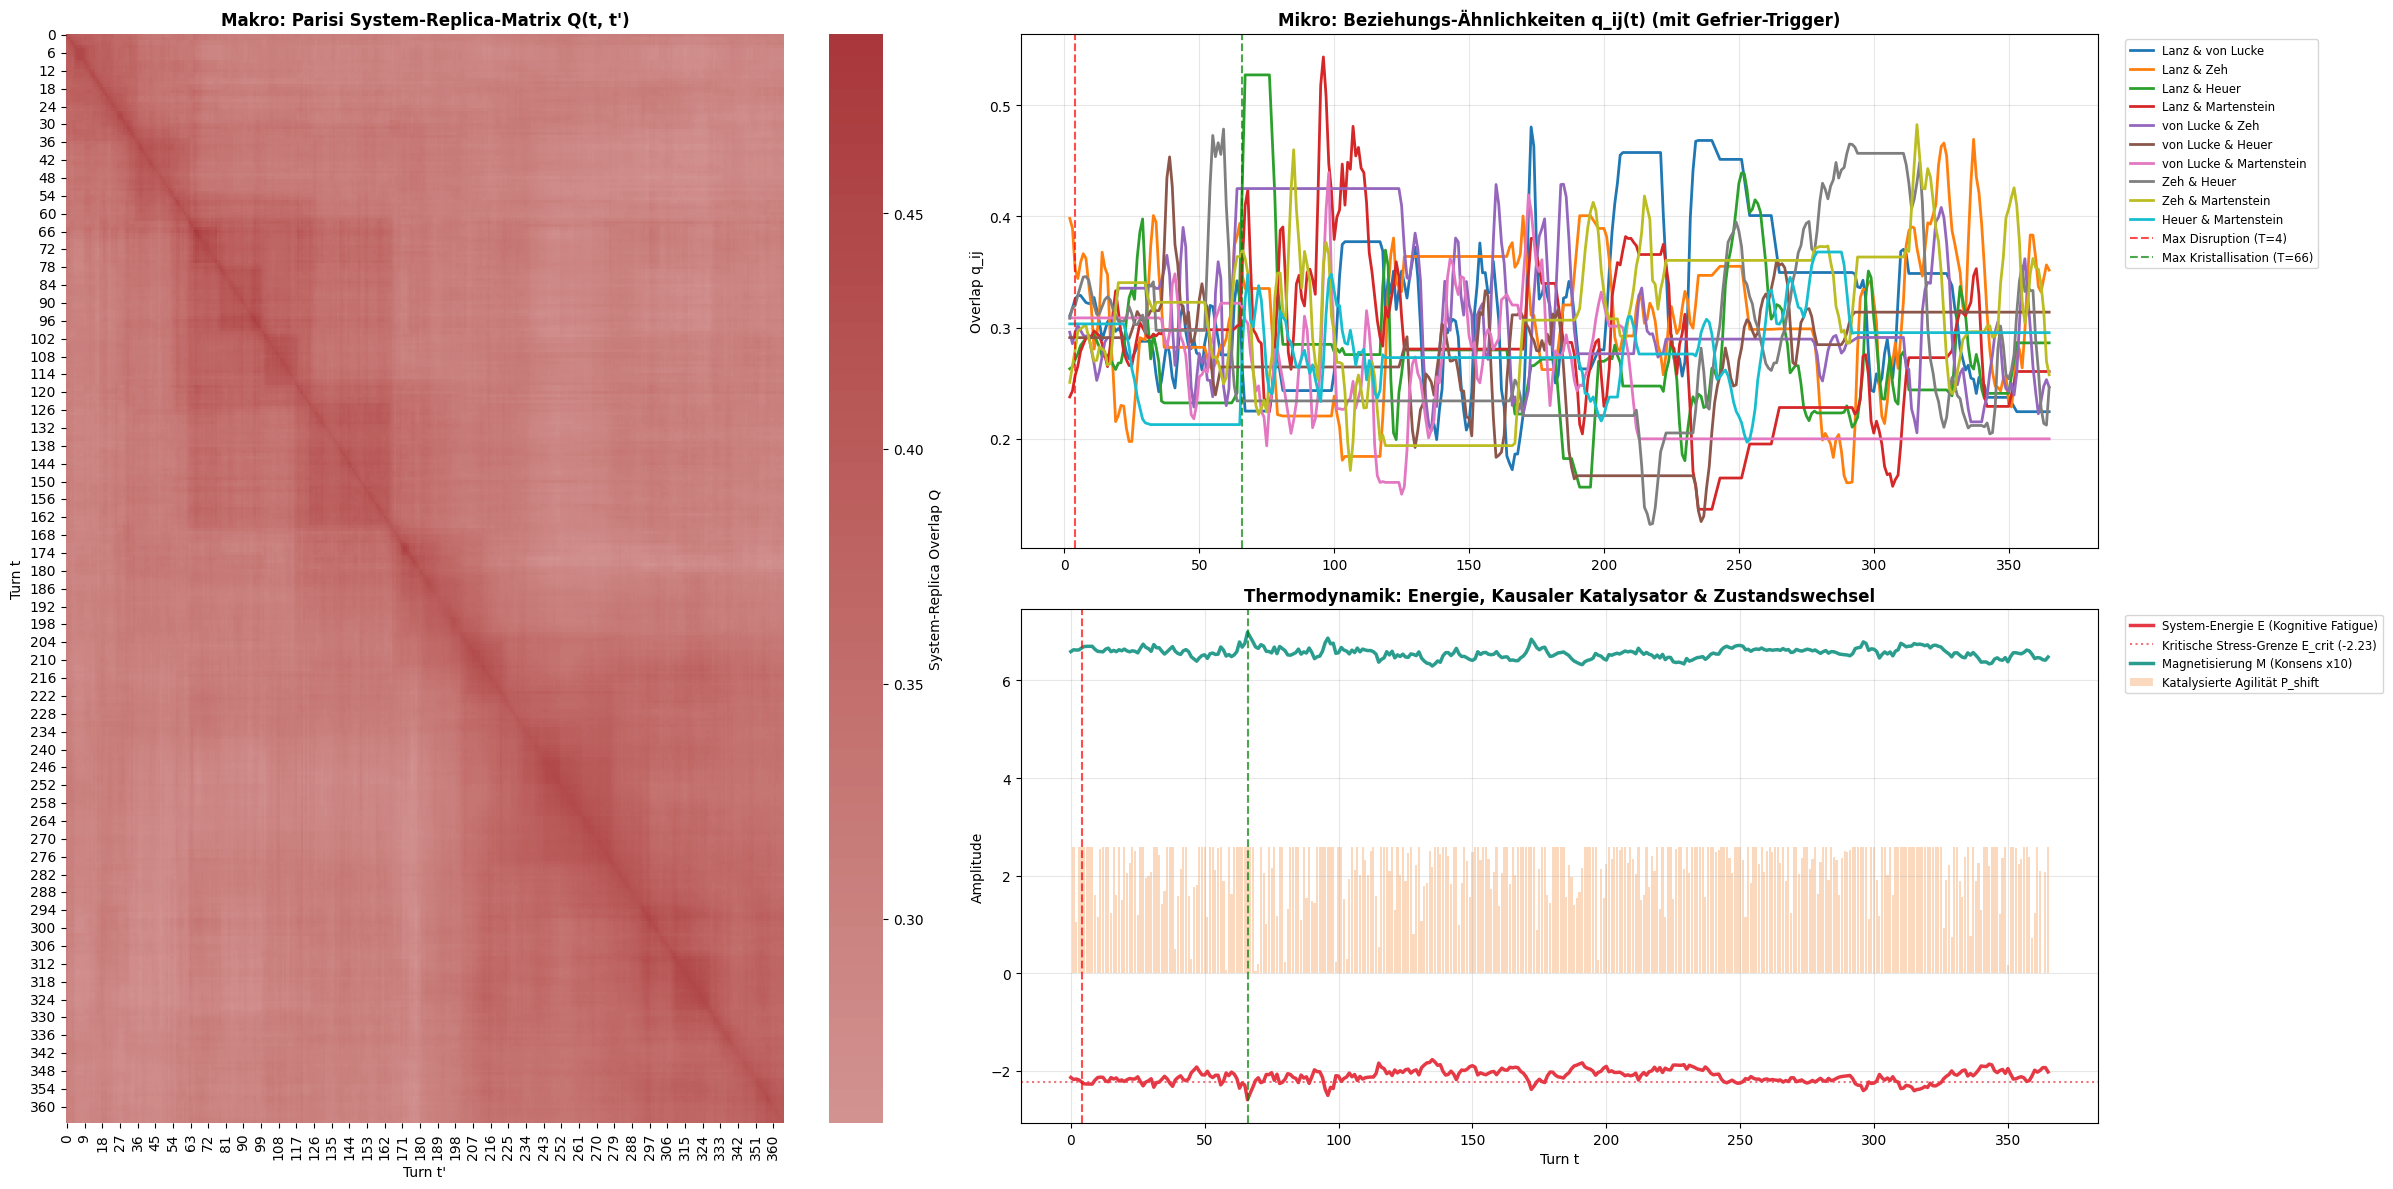

In [ ]:
# =====================================================================
# 8. MASTER-ADD-ON: THERMODYNAMISCHE PARISI-DYNAMIK & EMPIRISCHE TRIGGER
# (Inkl. dynamischer Kalibrierung von E_crit)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings("ignore")

print("\n" + "=" * 75)
print("⚛️ BERECHNE PARISI-THERMODYNAMIK MIT DYNAMISCHEN SCHWELLENWERTEN")
print("=" * 75)

num_speakers = len(names)
vector_dim_text = embeddings.shape[1]

# --- 1. Empirisch kalibrierte Viskosität (beta) ---
sigma_squared_raw = np.zeros(num_speakers)
arousal_array = df["ar"].values.astype(float)

for i in range(num_speakers):
    speaker_turns = np.where(df["sp"].values == i)[0]
    N_i = len(speaker_turns)
    if N_i > 1:
        ar_var = np.var(arousal_array[speaker_turns], ddof=1)
        d_var = np.var(d_scores[speaker_turns], ddof=1)
        sigma_squared_raw[i] = (ar_var + d_var) / 2.0
    else:
        sigma_squared_raw[i] = 0.0

max_var = np.max(sigma_squared_raw)
sigma_squared = (sigma_squared_raw / max_var) * 0.015 if max_var > 0 else np.zeros(num_speakers)
base_beta_values = 0.70 - (sigma_squared * 20)

# --- 2. Strukturelle Kopplung (Quenched Disorder J_ij über Pearson) ---
Phi_core = np.array(profiles_data)[:, 0:8]
Phi_core_norm = Phi_core / (np.linalg.norm(Phi_core, axis=1, keepdims=True) + 1e-9)
J_matrix = np.corrcoef(Phi_core)

# --- 3. Eichfeld-Zentrierung & Simulation der System-Replica ---
mean_emb = np.mean(embeddings, axis=0)
centered_emb = embeddings - mean_emb

speaker_sequence = df["sp"].values.astype(int)
spins_behavior = np.zeros((num_turns, num_speakers, vector_dim_text))
chi_states = np.zeros((num_turns, num_speakers, Phi_core.shape[1] + vector_dim_text))

current_behavior = np.random.randn(num_speakers, vector_dim_text)
current_behavior = current_behavior / np.linalg.norm(current_behavior, axis=1, keepdims=True)
w_core = 0.4
w_behav = 0.6

if 'K_index' not in locals():
    K_index = np.linspace(20, 70, num_turns)
if 'C_power' not in locals():
    C_power = np.maximum(0, d_scores)

k_threshold = np.mean(K_index)

for t in range(num_turns):
    sp_t = speaker_sequence[t]
    v_t = centered_emb[t] / (np.linalg.norm(centered_emb[t]) + 1e-9)

    current_K = K_index[t]
    freeze_factor = 0.1 if current_K > k_threshold else -0.1

    for i in range(num_speakers):
        b = np.clip(base_beta_values[i] + freeze_factor, 0.1, 0.95)
        if i == sp_t:
            new_b = b * current_behavior[i] + (1 - b) * v_t
        else:
            new_b = current_behavior[i]

        new_b = new_b / (np.linalg.norm(new_b) + 1e-9)
        current_behavior[i] = new_b
        spins_behavior[t, i] = new_b

        combined = np.concatenate([w_core * Phi_core_norm[i], w_behav * spins_behavior[t, i]])
        chi_states[t, i] = combined / (np.linalg.norm(combined) + 1e-9)

# --- 4. Parisi-Matrizen (Mikro q_ij und Makro Q) ---
Q_full_replica = np.zeros((num_turns, num_turns))
time_series_pairs = {}
q_matrix_t = np.zeros((num_turns, num_speakers, num_speakers))

for t in range(num_turns):
    for i in range(num_speakers):
        for j in range(num_speakers):
            q_val = np.dot(chi_states[t, i], chi_states[t, j])
            q_matrix_t[t, i, j] = q_val
            for t_prime in range(num_turns):
                Q_full_replica[t, t_prime] += np.dot(chi_states[t, i], chi_states[t_prime, j]) / (num_speakers**2)

for i in range(num_speakers):
    for j in range(i + 1, num_speakers):
        time_series_pairs[f"{names[i]} & {names[j]}"] = q_matrix_t[:, i, j]

# --- 5. Thermodynamik mit kausalem Katalysator & dynamischem E_crit ---
E_parisi = np.zeros(num_turns)
M_t = np.zeros(num_turns)
P_shift = np.zeros(num_turns)
epsilon = 0.01

for t in range(num_turns):
    M_vec = np.mean(chi_states[t], axis=0)
    M_t[t] = np.linalg.norm(M_vec)

    e_sum = 0
    for i in range(num_speakers):
        for j in range(i + 1, num_speakers):
            e_sum += J_matrix[i, j] * q_matrix_t[t, i, j]
    E_parisi[t] = -e_sum

# NEU: Dynamische Kalibrierung von E_crit (unteres 15%-Perzentil der Energie als Krisen-Zone)
E_crit = np.percentile(E_parisi, 15)
print(f"🎯 Dynamisch kalibrierte kritische Energiegrenze (E_crit): {E_crit:.3f}")

for t in range(1, num_turns):
    delta_E = E_parisi[t] - E_parisi[t-1]
    c_factor = C_power[t]
    T_eff = abs(d_scores[t]) * (1.0 + max(0, c_factor)) + epsilon

    if delta_E <= 0 or E_parisi[t] < E_crit:
        P_shift[t] = 1.0
    else:
        P_shift[t] = np.exp(-delta_E / T_eff)

# --- 6. Dynamische Ermittlung der Wendepunkte ---
turn_max_disruption = np.argmax(d_scores)
turn_max_consensus = np.argmax(M_t)

# =====================================================================
# 9. ERWEITERTE VISUALISIERUNG: MAKRO, MIKRO & THERMODYNAMIK
# =====================================================================
fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1.2])

# Panel 1: Makro-Matrix Q(t, t')
ax1 = fig.add_subplot(gs[:, 0])
sns.heatmap(Q_full_replica, ax=ax1, cmap='vlag', center=0, cbar_kws={'label': 'System-Replica Overlap Q'})
ax1.set_title("Makro: Parisi System-Replica-Matrix Q(t, t')", fontweight='bold')
ax1.set_xlabel("Turn t'")
ax1.set_ylabel("Turn t")

# Panel 2: Mikro-Zeitreihen q_ij(t)
ax2 = fig.add_subplot(gs[0, 1])
for pair_name, values in time_series_pairs.items():
    smoothed = np.convolve(values, np.ones(3)/3, mode='valid')
    ax2.plot(range(2, num_turns), smoothed, label=pair_name, linewidth=2)

ax2.axvline(x=turn_max_disruption, color='red', linestyle='--', alpha=0.7, label=f'Max Disruption (T={turn_max_disruption})')
ax2.axvline(x=turn_max_consensus, color='green', linestyle='--', alpha=0.7, label=f'Max Kristallisation (T={turn_max_consensus})')

ax2.set_title("Mikro: Beziehungs-Ähnlichkeiten q_ij(t) (mit Gefrier-Trigger)", fontweight='bold')
ax2.set_ylabel("Overlap q_ij")
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
ax2.grid(True, alpha=0.3)

# Panel 3: Thermodynamik inkl. Kausalem Katalysator und dynamischer Krisenzone
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(range(num_turns), E_parisi, color='#e63946', linewidth=2.5, label='System-Energie E (Kognitive Fatigue)')
ax3.axhline(y=E_crit, color='#e63946', linestyle=':', alpha=0.7, label=f'Kritische Stress-Grenze E_crit ({E_crit:.2f})')
ax3.plot(range(num_turns), M_t * 10, color='#2a9d8f', linewidth=2.5, label='Magnetisierung M (Konsens x10)')
ax3.bar(range(num_turns), P_shift * np.max(abs(E_parisi)), color='#f4a261', alpha=0.4, label='Katalysierte Agilität P_shift')

ax3.axvline(x=turn_max_disruption, color='red', linestyle='--', alpha=0.7)
ax3.axvline(x=turn_max_consensus, color='green', linestyle='--', alpha=0.7)

ax3.set_title("Thermodynamik: Energie, Kausaler Katalysator & Zustandswechsel", fontweight='bold')
ax3.set_xlabel("Turn t")
ax3.set_ylabel("Amplitude")
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🌳 BERECHNE PARISI HIERARCHIE-BAUM (DYNAMISCH AN UPSILON GEKOPPELT)


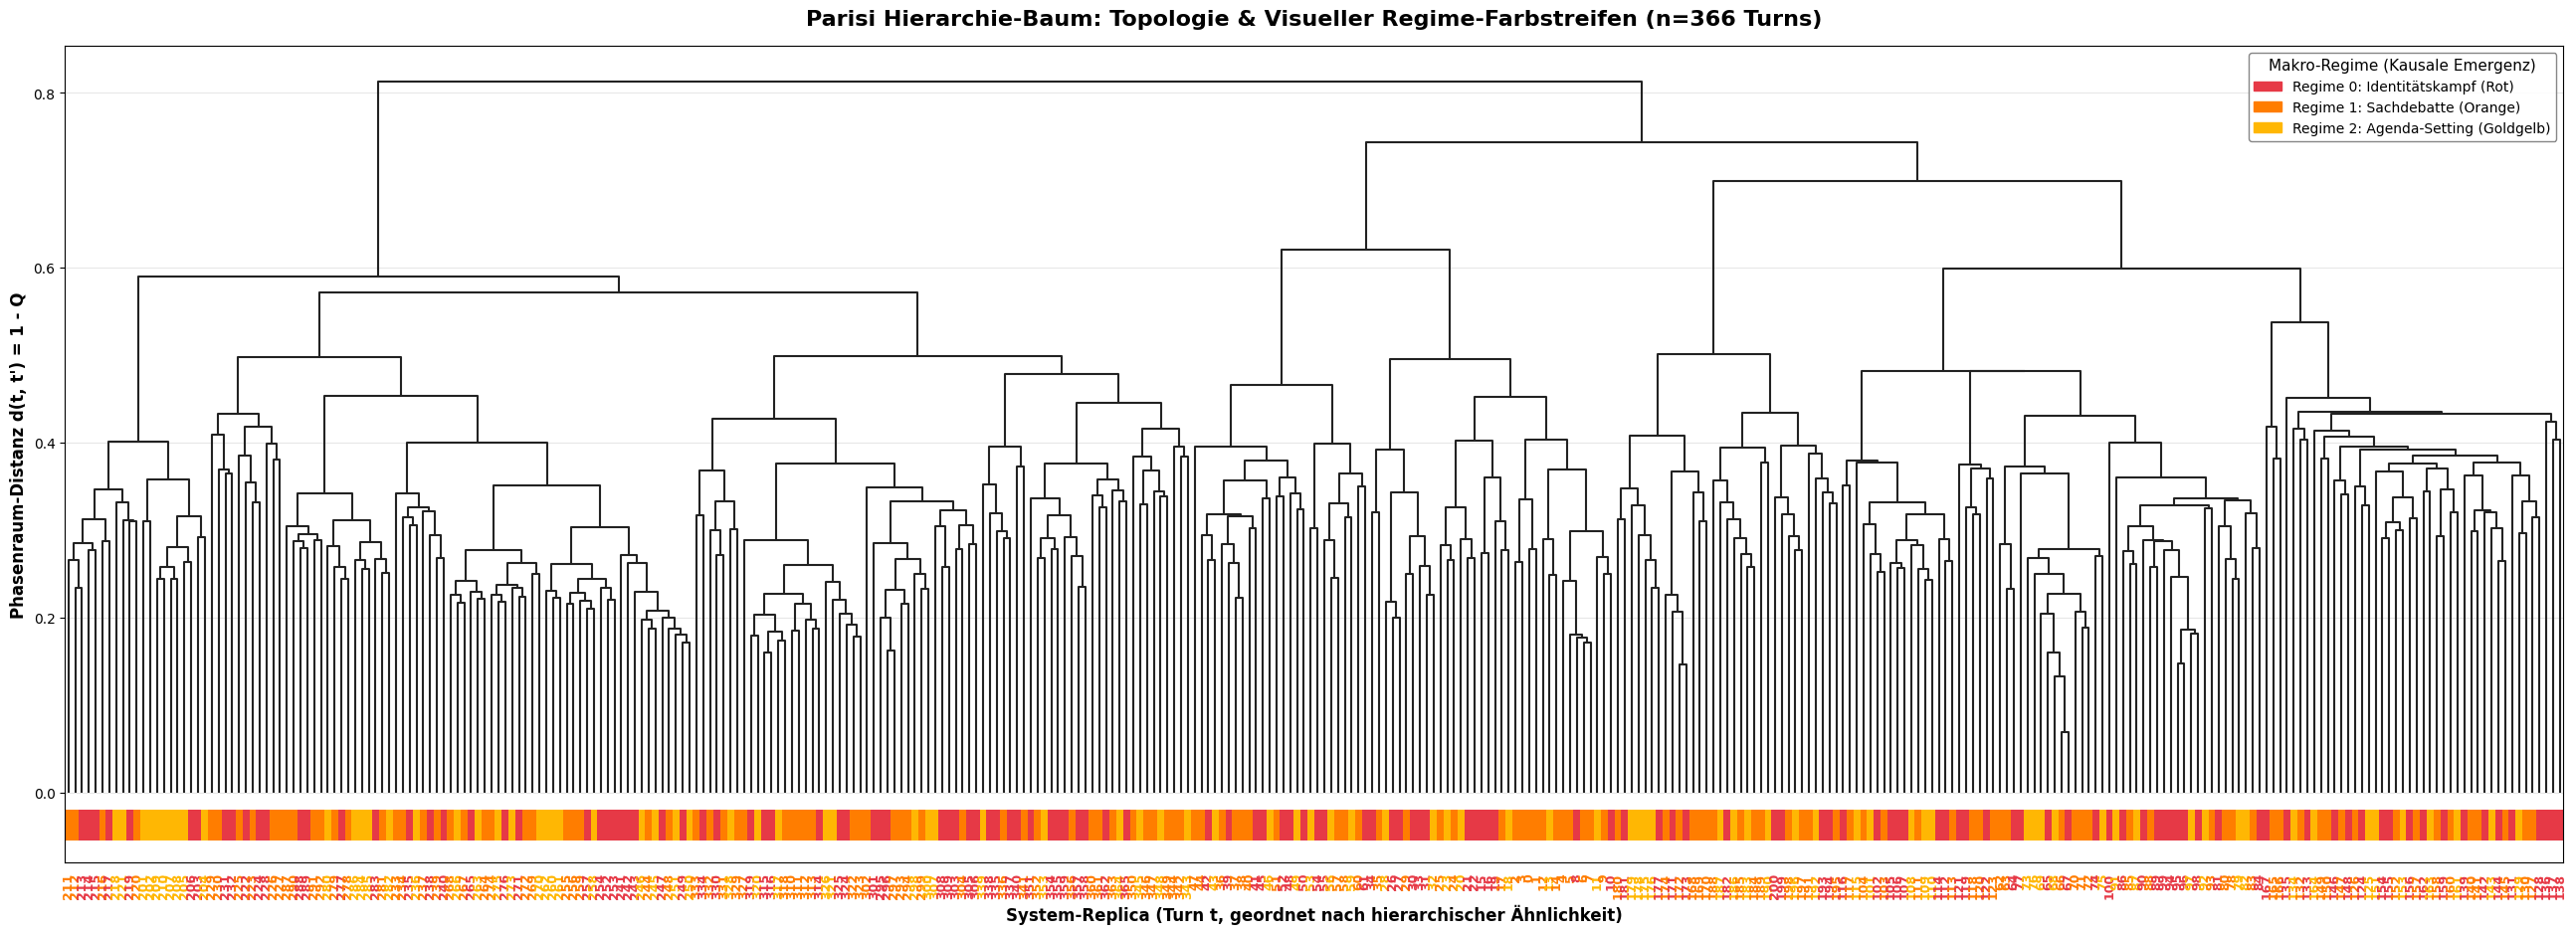

In [ ]:
# =====================================================================
# 10. ADD-ON: PARISI HIERARCHIE-BAUM (DYNAMISCH GEKOPPELT)
# =====================================================================
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 75)
print("🌳 BERECHNE PARISI HIERARCHIE-BAUM (DYNAMISCH AN UPSILON GEKOPPELT)")
print("=" * 75)

# 1. Distanzmatrix aus dem Parisi-Overlap Q(t, t') berechnen
Q_min = np.min(Q_full_replica)
Q_max = np.max(Q_full_replica)
Q_norm = (Q_full_replica - Q_min) / (Q_max - Q_min + 1e-9)
distance_matrix = 1.0 - Q_norm

distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)

# 2. Hierarchisches Clustering
condensed_dist = ssd.squareform(distance_matrix)
Z = sch.linkage(condensed_dist, method='average')

# 3. Parisi-Baum im klassischen Format zeichnen
fig_tree, ax_tree = plt.subplots(figsize=(26, 9.5))

dendro = sch.dendrogram(
    Z,
    labels=range(num_turns),
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color='#222222',
    ax=ax_tree
)

# 4. Dynamische Farbdefinitionen passend zur Systemdiagnose
regime_colors = {
    0: '#e63946',  # Regime 0: Rot (Identitätskampf)
    1: '#ff7d00',  # Regime 1: Orange (Sachdebatte)
    2: '#ffb703'   # Regime 2: Goldgelb (Agenda-Setting)
}

def get_regime_color(turn_idx):
    # Greift auf das dynamische Upsilon-Array aus dem vorherigen Modul zu
    if turn_idx < len(causal_emergence_clusters):
        regime = causal_emergence_clusters[turn_idx]
        return regime_colors.get(regime, '#888888') # Fallback nur bei fehlendem Index
    return '#888888'

# 5. Exaktes Einfärben der Blätter
for label in ax_tree.get_xticklabels():
    turn_idx = int(label.get_text())
    label.set_color(get_regime_color(turn_idx))
    label.set_fontweight('bold')

# 6. Visuellen Regime-Farbstreifen (Color Bar) unterhalb der x-Achse einfügen
# Wir holen die exakte Blatt-Reihenfolge (ivl) des Dendrogramms von links nach rechts
ivl_turns = [int(t) for t in dendro['ivl']]

y_bar_top = -0.02
y_bar_height = 0.035
for idx, turn_idx in enumerate(ivl_turns):
    x_center = (idx * 10) + 5
    color = get_regime_color(turn_idx)

    rect = plt.Rectangle(
        (x_center - 5, y_bar_top - y_bar_height), 10, y_bar_height,
        facecolor=color, edgecolor='none', transform=ax_tree.transData, clip_on=False
    )
    ax_tree.add_patch(rect)

# Achsen-Limits anpassen, damit der Farbstreifen perfekt Platz hat
ax_tree.set_ylim(-0.08, max(Z[:, 2]) * 1.05)

# 7. Dynamisierte Legende
legend_patches = [
    mpatches.Patch(color=regime_colors[0], label='Regime 0: Identitätskampf (Rot)'),
    mpatches.Patch(color=regime_colors[1], label='Regime 1: Sachdebatte (Orange)'),
    mpatches.Patch(color=regime_colors[2], label='Regime 2: Agenda-Setting (Goldgelb)')
]
ax_tree.legend(handles=legend_patches, loc='upper right', title="Makro-Regime (Kausale Emergenz)",
               fontsize=10, title_fontsize=11, framealpha=0.95, edgecolor='gray')

ax_tree.set_title(f"Parisi Hierarchie-Baum: Topologie & Visueller Regime-Farbstreifen (n={num_turns} Turns)", fontweight='bold', fontsize=16, pad=15)
ax_tree.set_ylabel("Phasenraum-Distanz d(t, t') = 1 - Q", fontweight='bold', fontsize=12)
ax_tree.set_xlabel("System-Replica (Turn t, geordnet nach hierarchischer Ähnlichkeit)", fontweight='bold', fontsize=12)
ax_tree.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# HIERARCHISCHE TIEFENANALYSE (ECHTES NLP-TAGGING FÜR SUBSTANTIVE)
# =====================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.cluster.hierarchy as sch
import numpy as np
import spacy

# 1. Deutsches NLP-Modell laden (installiert es automatisch im Colab, falls nicht vorhanden)
try:
    nlp = spacy.load("de_core_news_sm")
except OSError:
    import os
    os.system("python -m spacy download de_core_news_sm")
    nlp = spacy.load("de_core_news_sm")

# ⚙️ KONFIGURATION
NUM_MAIN = 2
NUM_SUB = 6

print("\n" + "=" * 75)
print(f"🌳 HIERARCHISCHE BAUM-ANALYSE: {NUM_MAIN} HAUPTÄSTE -> {NUM_SUB} SUB-ÄSTE")
print("=" * 75)

main_branches = sch.fcluster(Z, t=NUM_MAIN, criterion='maxclust')
sub_branches = sch.fcluster(Z, t=NUM_SUB, criterion='maxclust')
df['main_branch'] = main_branches
df['sub_branch'] = sub_branches

tree_map = {1: [], 2: []}
for i in range(len(main_branches)):
    main_id = main_branches[i]
    sub_id = sub_branches[i]
    if sub_id not in tree_map[main_id]:
        tree_map[main_id].append(sub_id)

for m in tree_map:
    tree_map[m].sort()

# Hilfsfunktion: Isoliert Nomen und Adjektiv+Nomen-Paare
def extract_substantives_only(text_list):
    docs = nlp.pipe([str(t) for t in text_list])
    processed = []
    for doc in docs:
        extracted = []
        for i, token in enumerate(doc):
            if token.pos_ in ['NOUN', 'PROPN']:
                # Wenn das Wort davor ein Adjektiv ist, verbinde sie
                if i > 0 and doc[i-1].pos_ == 'ADJ':
                    extracted.append(f"{doc[i-1].text}_{token.text}")
                else:
                    extracted.append(token.text)
        processed.append(" ".join(extracted))
    return processed

# Wir behalten zur Sicherheit einen Basis-Filter für sehr generische Nomen
generic_nouns = ['herr', 'frau', 'jahr', 'jahre', 'jahren', 'zeit', 'fall', 'thema', 'frage', 'leute', 'satz', 'ding', 'dinge', 'seite', 'bisschen']

for main_id in [1, 2]:
    main_turns = df[df['main_branch'] == main_id]
    if len(main_turns) == 0: continue

    print(f"\n{'='*60}")
    print(f"🌲 HAUPTAST {main_id} (Umfasst {len(main_turns)} Turns)")
    print(f"{'='*60}")

    sub_counter = 1
    for sub_id in tree_map[main_id]:
        branch_turns = df[df['sub_branch'] == sub_id]
        if len(branch_turns) == 0: continue

        turn_indices = branch_turns.index.tolist()
        print(f"\n   🔹 Ast {main_id}.{sub_counter} (Umfasst {len(branch_turns)} Turns)")

        # --- A. Grammatikalisch gefilterte Schlagworte ---
        raw_texts = branch_turns['text'].tolist()
        noun_only_texts = extract_substantives_only(raw_texts)

        try:
            vectorizer = TfidfVectorizer(
                stop_words=generic_nouns,
                max_df=0.6,
                min_df=2,
                ngram_range=(1, 1) # Ngram=1 reicht, da Adj+Nomen bereits als "Gute_Stimmung" verbunden sind
            )
            tfidf_matrix = vectorizer.fit_transform(noun_only_texts)
            scores = tfidf_matrix.sum(axis=0).A1

            top_idx = scores.argsort()[::-1]
            top_words = []
            for i in top_idx:
                # Underscore wieder durch Leerzeichen ersetzen für die Ausgabe
                word = vectorizer.get_feature_names_out()[i].replace('_', ' ').title()
                if len(word) > 2:
                    top_words.append(word)
                if len(top_words) == 4:
                    break

            if top_words:
                print(f"      Inhalt: {', '.join(top_words)}")
            else:
                print("      Inhalt: Keine distinkten Begriffe")
        except ValueError:
            print("      Inhalt: Divers / Rauschen")

        # --- B. Makro-Regime Verteilung in diesem Ast ---
        ast_regimes = causal_emergence_clusters[turn_indices]
        total = len(ast_regimes)

        if total > 0:
            r0 = np.sum(ast_regimes == 0)
            r1 = np.sum(ast_regimes == 1)
            r2 = np.sum(ast_regimes == 2)

            dom_idx = np.argmax([r0, r1, r2])
            dom_name = ["Rot (Identitätskampf)", "Orange (Sachdebatte)", "Gelb (Agenda-Setting)"][dom_idx]

            print(f"      Dominanz: {dom_name}")
            print(f"      Verteilung: Rot ({r0/total*100:.0f}%) | Orange ({r1/total*100:.0f}%) | Gelb ({r2/total*100:.0f}%)")

        sub_counter += 1


🌳 HIERARCHISCHE BAUM-ANALYSE: 2 HAUPTÄSTE -> 6 SUB-ÄSTE

🌲 HAUPTAST 1 (Umfasst 165 Turns)

   🔹 Ast 1.1 (Umfasst 165 Turns)
      Inhalt: England, Migration, Gefühl, Grund
      Dominanz: Orange (Sachdebatte)
      Verteilung: Rot (36%) | Orange (38%) | Gelb (26%)

🌲 HAUPTAST 2 (Umfasst 201 Turns)

   🔹 Ast 2.1 (Umfasst 26 Turns)
      Inhalt: Stimmung, Weimar, Lage, Level
      Dominanz: Rot (Identitätskampf)
      Verteilung: Rot (38%) | Orange (38%) | Gelb (23%)

   🔹 Ast 2.2 (Umfasst 36 Turns)
      Inhalt: Deutschland, Gefühl, Stimmung, Okay
      Dominanz: Orange (Sachdebatte)
      Verteilung: Rot (36%) | Orange (44%) | Gelb (19%)

   🔹 Ast 2.3 (Umfasst 33 Turns)
      Inhalt: Afd, Normale Partei, Martenstein, Muss
      Dominanz: Orange (Sachdebatte)
      Verteilung: Rot (27%) | Orange (42%) | Gelb (30%)

   🔹 Ast 2.4 (Umfasst 62 Turns)
      Inhalt: Cdu, Einen Seite, Stimmung, Politische Richtung
      Dominanz: Rot (Identitätskampf)
      Verteilung: Rot (42%) | Orange (32%


⛰️ BERECHNE THERMODYNAMISCHE ENERGIELANDSCHAFT (3D & 2D MAP)


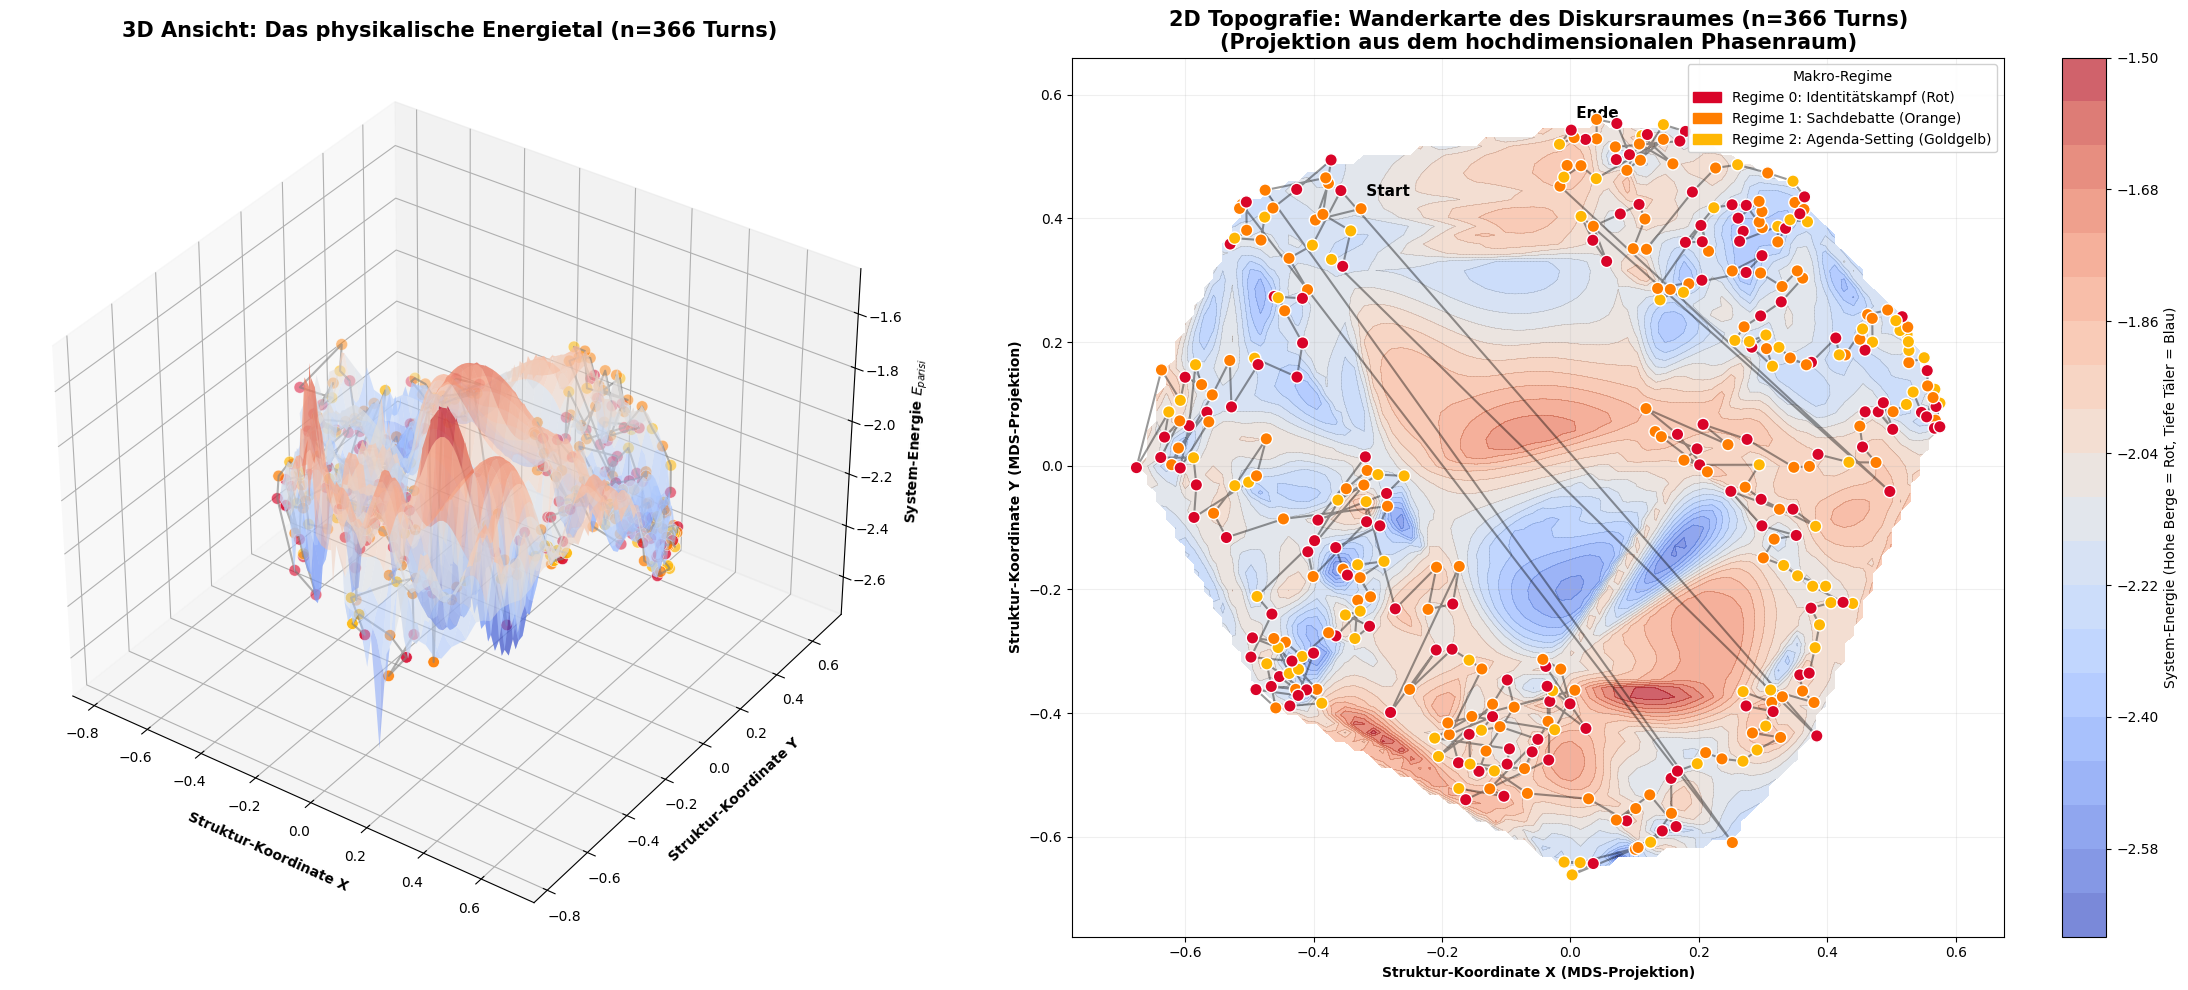

In [ ]:
# =====================================================================
# 11. ADD-ON: DIE THERMODYNAMISCHE ENERGIELANDSCHAFT (3D & 2D TOPOGRAFIE)
# (Vollständig flexibilisiert und an Upsilon-Regime gekoppelt)
# =====================================================================
from sklearn.manifold import MDS
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("\n" + "=" * 75)
print("⛰️ BERECHNE THERMODYNAMISCHE ENERGIELANDSCHAFT (3D & 2D MAP)")
print("=" * 75)

# 1. MDS Projektion: Von N Dimensionen in die flache x/y-Ebene
# Nutzt die im vorherigen Schritt berechnete distance_matrix und n=num_turns
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, max_iter=3000)
coords_2d = mds.fit_transform(distance_matrix)
x_coords = coords_2d[:, 0]
y_coords = coords_2d[:, 1]

# 2. Oberfläche interpolieren (Das "Gebirge" berechnen)
grid_x, grid_y = np.mgrid[min(x_coords)-0.1:max(x_coords)+0.1:100j,
                          min(y_coords)-0.1:max(y_coords)+0.1:100j]

grid_z = griddata(coords_2d, E_parisi, (grid_x, grid_y), method='cubic')

# 3. Dynamische Farbdefinitionen (Gleiche Palette wie im Hierarchie-Baum)
regime_colors = {
    0: '#d90429',  # Regime 0: Signalrot (Identitätskampf)
    1: '#ff7d00',  # Regime 1: Orange (Sachdebatte)
    2: '#ffb703'   # Regime 2: Goldgelb (Agenda-Setting)
}

def get_dynamic_regime_color(turn_idx):
    if turn_idx < len(causal_emergence_clusters):
        regime = causal_emergence_clusters[turn_idx]
        return regime_colors.get(regime, '#888888')
    return '#888888'

colors = [get_dynamic_regime_color(t) for t in range(num_turns)]

# 4. Das Dashboard mit zwei Subplots erstellen
fig_landscape = plt.figure(figsize=(24, 10))

# --- LINKER PLOT: 3D OBERFLÄCHE ---
ax_3d = fig_landscape.add_subplot(121, projection='3d')
surf = ax_3d.plot_surface(grid_x, grid_y, grid_z, cmap='coolwarm',
                          alpha=0.5, linewidth=0, antialiased=True)

# Pfad und Punkte in 3D (Z-Achse ist E_parisi)
ax_3d.plot(x_coords, y_coords, E_parisi, color='gray', alpha=0.6, linewidth=1.5, zorder=3)
ax_3d.scatter(x_coords, y_coords, E_parisi, c=colors, s=70, edgecolors='white', linewidth=0.5, zorder=4)

ax_3d.set_title(f"3D Ansicht: Das physikalische Energietal (n={num_turns} Turns)", fontweight='bold', fontsize=15, pad=15)
ax_3d.set_xlabel("\nStruktur-Koordinate X", fontweight='bold')
ax_3d.set_ylabel("\nStruktur-Koordinate Y", fontweight='bold')
ax_3d.set_zlabel("\nSystem-Energie $E_{parisi}$", fontweight='bold')
ax_3d.view_init(elev=35, azim=-55)

# --- RECHTER PLOT: 2D TOPOGRAFIE WANDERKARTE ---
ax_2d = fig_landscape.add_subplot(122)
contour = ax_2d.contourf(grid_x, grid_y, grid_z, levels=20, cmap='coolwarm', alpha=0.7)
plt.colorbar(contour, ax=ax_2d, label='System-Energie (Hohe Berge = Rot, Tiefe Täler = Blau)')

ax_2d.contour(grid_x, grid_y, grid_z, levels=20, colors='black', linewidths=0.2, alpha=0.5)

ax_2d.plot(x_coords, y_coords, color='black', alpha=0.4, linewidth=1.5, zorder=3)
ax_2d.scatter(x_coords, y_coords, c=colors, s=80, edgecolors='white', linewidth=1, zorder=4)

# Start und Endpunkt markieren
ax_2d.text(x_coords[0], y_coords[0]+0.02, ' Start', color='black', fontweight='bold', fontsize=11)
ax_2d.text(x_coords[-1], y_coords[-1]+0.02, ' Ende', color='black', fontweight='bold', fontsize=11)

ax_2d.set_title(f"2D Topografie: Wanderkarte des Diskursraumes (n={num_turns} Turns)\n(Projektion aus dem hochdimensionalen Phasenraum)", fontweight='bold', fontsize=15)
ax_2d.set_xlabel("Struktur-Koordinate X (MDS-Projektion)", fontweight='bold')
ax_2d.set_ylabel("Struktur-Koordinate Y (MDS-Projektion)", fontweight='bold')
ax_2d.grid(alpha=0.2)

# Legende für die Regime hinzufügen
legend_patches = [
    mpatches.Patch(color=regime_colors[0], label='Regime 0: Identitätskampf (Rot)'),
    mpatches.Patch(color=regime_colors[1], label='Regime 1: Sachdebatte (Orange)'),
    mpatches.Patch(color=regime_colors[2], label='Regime 2: Agenda-Setting (Goldgelb)')
]
ax_2d.legend(handles=legend_patches, loc='upper right', title="Makro-Regime", framealpha=0.9)

plt.tight_layout()
plt.show()